In [459]:
import pandas as pd
import numpy as np

In [460]:
path_data = "./data/houses_Madrid.csv"

In [461]:
df = pd.read_csv(path_data, index_col=0)

In [462]:
df.head()

,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,...,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,NaN,...,D,False,NaN,NaN,NaN,NaN,False,True,False,False
1,21741,Piso en venta en calle de la del Manojo de Rosas,"Los Ángeles, Madrid",70.0,NaN,3,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21740,"Piso en venta en calle del Talco, 68","San Andrés, Madrid",94.0,54.0,2,2.0,NaN,NaN,NaN,...,no indicado,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21739,Piso en venta en calle Pedro Jiménez,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,False,True,False
4,21738,Piso en venta en carretera de Villaverde a Val...,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True


In [463]:
AMENITY_COLS = [
    "has_ac", #
    "has_fitted_wardrobes",
    "has_lift",#
    "is_exterior",
    "has_pool",
    "has_terrace",
    "has_garden",
    "has_balcony",
    "has_storage_room",
    "is_accessible",
    "has_green_zones",
    "has_central_heating",
]
 
ORIENTATION_COLS = [
    "is_orientation_north",
    "is_orientation_south",
    "is_orientation_east",
    "is_orientation_west",
]
 
REFERENCE_DUMMIES = ["house_type_id_Misc", "district_id_21"] # prevent perfect multicollinearity

COLS_TO_DROP_FINAL = ["id", "title", "street_name", "street_number", "rent_price", 
                      "buy_price_by_area",      # ← direct leakage: derived from target
                    "is_buy_price_known",     # ← also leakage: flags whether buy_price exists
                        ]

buy_price_by_area is computed as buy_price / sq_mt_built. You cannot know buy_price before predicting buy_price. The column is physically absent for every new unseen listing. The model you trained has never learned to predict price — it learned to reverse-engineer a number that won't be there.

In [464]:
def curate_df(df: pd.DataFrame, missing_threshold: float = 0.5) -> pd.DataFrame:
    """
    Remove columns whose missing-value ratio exceeds `missing_threshold`.
 
    Parameters
    ----------
    df : pd.DataFrame
        Raw input dataframe.
    missing_threshold : float, default 0.5
        Fraction threshold (0.0–1.0).  Columns with missing ratio
        strictly above this value are dropped.
 
    Returns
    -------
    pd.DataFrame
        Copy of df with sparse columns removed.
    """
    df_copy = df.copy()
 
    missing_ratio = df_copy.isna().sum() / len(df_copy)
    cols_to_drop  = missing_ratio[missing_ratio > missing_threshold].index.tolist()
 
    if cols_to_drop:
        print(f"[curate_df] Dropping {len(cols_to_drop)} columns "
              f"(>{missing_threshold*100:.0f}% missing):")
        for col in cols_to_drop:
            print(f"  • {col}: {missing_ratio[col]*100:.1f}% missing")
    else:
        print(f"[curate_df] No columns exceed "
              f"{missing_threshold*100:.0f}% missing threshold.")
 
    df_out = df_copy.drop(columns=cols_to_drop)
    print(f"[curate_df] Shape: {df.shape} → {df_out.shape}\n")
    return df_out
 

In [465]:
def filter_built_year(df: pd.DataFrame,
                      min_year: int = 1850,
                      max_year: int | None = 2022) -> pd.DataFrame:
    """
 
    Madrid's modern cadastral records start around the mid-19th century.
 
    Parameters
    ----------
    df : pd.DataFrame
    min_year : int, default 1850
        Minimum plausible construction year (inclusive).
    max_year : int or None, default None
        Maximum plausible year (inclusive).  Defaults to current year.
 
    Returns
    -------
    pd.DataFrame
        Filtered copy.
    """
    if "built_year" not in df.columns:
        print("[filter_built_year] 'built_year' column not found — skipping.")
        return df.copy()
 
    if max_year is None:
        max_year = pd.Timestamp.now().year
 
    df_copy  = df.copy()
    original = len(df_copy)
 
    # Rows where built_year is recorded but outside valid range
    has_year    = df_copy["built_year"].notna()
    valid_range = df_copy["built_year"].between(min_year, max_year)
    mask_keep   = (~has_year) | valid_range          # keep NaN OR valid
 
    df_out  = df_copy[mask_keep]
    dropped = original - len(df_out)
 
    print(f"[filter_built_year] Removed {dropped} rows with "
          f"built_year outside [{min_year}, {max_year}].")
    print(f"[filter_built_year] Shape: {df.shape} → {df_out.shape}\n")
    
    return df_out

In [466]:
def fill_amenities_by_year(df: pd.DataFrame,
                           amenity_cols: list[str] | None = None,
                           year_col: str = "built_year",
                           bin_width: int = 5) -> pd.DataFrame:
    """
    Impute missing boolean amenity flags using the mode within
    the same construction-year cohort (decade bin), then fall back
    to the global mode for any remaining NaNs.
 
    Why group imputation over simple fillna(False)
    ------------------------------------------------
    Amenity prevalence is strongly era-dependent:
      - Lifts are rare in pre-1960 walk-ups but near-universal post-2000.
      - AC penetration surged after ~1990.
      - Accessible buildings only became standard post-2000 (building codes).
    Imputing False unconditionally would systematically under-count
    amenities in newer buildings and over-count in older ones.
    Using decade-bin mode preserves these temporal patterns.
 
    Fall-back hierarchy
    -------------------
    1. Mode within the same 10-year bin.
    2. Global mode (for bins with only one observation or all-NaN).
    3. False (if column is entirely missing — shouldn't happen post curate_df).
 
    Parameters
    ----------
    df : pd.DataFrame
    amenity_cols : list[str] or None
        Columns to impute.  Defaults to AMENITY_COLS global.
    year_col : str, default 'built_year'
        Column used for binning.
    bin_width : int, default 10
        Width (in years) of each cohort bin.
 
    Returns
    -------
    pd.DataFrame
        Copy with amenity NaNs filled.
    """
    if amenity_cols is None:
        amenity_cols = AMENITY_COLS
 
    df_copy = df.copy()
    present_cols = [c for c in amenity_cols if c in df_copy.columns]
 
    if not present_cols:
        print("[fill_amenities_by_year] No amenity columns found — skipping.")
        return df_copy
 
    # --- Build decade bins ------------------------------------------------
    if year_col in df_copy.columns and df_copy[year_col].notna().any():
        yr = df_copy[year_col].dropna()
        bin_min = int(yr.min() // bin_width) * bin_width
        bin_max = int(yr.max() // bin_width) * bin_width + bin_width
        bins    = list(range(bin_min, bin_max + bin_width, bin_width))
        df_copy["_year_bin"] = pd.cut(df_copy[year_col], bins=bins,
                                      right=False, labels=False)
    else:
        df_copy["_year_bin"] = np.nan
 
    # --- Global mode per column (fallback) --------------------------------
    global_modes = {
        col: (df_copy[col].mode()[0] if not df_copy[col].mode().empty else False)
        for col in present_cols
    }
 
    # --- Group-wise mode imputation ----------------------------------------
    def _fill_col(group, col):
        """Fill NaNs in `col` within a group using that group's mode."""
        if group[col].isna().all():
            return group[col].fillna(global_modes[col])
        mode_val = group[col].mode()[0]
        return group[col].fillna(mode_val)
 
    for col in present_cols:
        if df_copy[col].isna().any():

            # transform preserves original index — no alignment mismatch
            def _mode_fill(group):
                if group.isna().all():
                    return group.fillna(global_modes[col])
                return group.fillna(group.mode()[0])

            df_copy[col] = df_copy.groupby(
                "_year_bin", group_keys=False
            )[col].transform(_mode_fill)

            # Final fallback — rows with no built_year get no bin
            df_copy[col] = df_copy[col].fillna(global_modes[col])
 
    df_copy.drop(columns="_year_bin", inplace=True)
 
    filled = sum(df[c].isna().sum() for c in present_cols)
    print(f"[fill_amenities_by_year] Filled {filled} total NaNs "
          f"across {len(present_cols)} amenity columns.\n")
    return df_copy

In [467]:
df_test = fill_amenities_by_year(df)

[fill_amenities_by_year] Filled 149206 total NaNs across 12 amenity columns.



In [468]:
df_test.head()

,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,...,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,NaN,...,D,False,NaN,NaN,NaN,NaN,False,True,False,False
1,21741,Piso en venta en calle de la del Manojo de Rosas,"Los Ángeles, Madrid",70.0,NaN,3,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21740,"Piso en venta en calle del Talco, 68","San Andrés, Madrid",94.0,54.0,2,2.0,NaN,NaN,NaN,...,no indicado,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21739,Piso en venta en calle Pedro Jiménez,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,False,True,False
4,21738,Piso en venta en carretera de Villaverde a Val...,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True


In [469]:
def fill_orientation(df: pd.DataFrame,
                     orientation_cols: list[str] | None = None) -> pd.DataFrame:
    """
    Fill missing orientation flags (is_orientation_*) with each
    column's global mode (most common observed value).
 
    Why mode, not False?
    --------------------
    Orientation is recorded per listing, not derived from the building.
    Missing values are usually a data-collection gap, not an indication
    that the property lacks an orientation.  The mode is the safest
    neutral imputation that doesn't bias directional distributions.
 
    Parameters
    ----------
    df : pd.DataFrame
    orientation_cols : list[str] or None
        Defaults to ORIENTATION_COLS global.
 
    Returns
    -------
    pd.DataFrame
        Copy with orientation NaNs filled.
    """
    if orientation_cols is None:
        orientation_cols = ORIENTATION_COLS
 
    df_copy      = df.copy()
    present_cols = [c for c in orientation_cols if c in df_copy.columns]
 
    for col in present_cols:
        if df_copy[col].isna().any():
            mode_val = df_copy[col].mode()
            fill_val = mode_val[0] if not mode_val.empty else False
            n_filled = df_copy[col].isna().sum()
            df_copy[col] = df_copy[col].fillna(fill_val)
            print(f"[fill_orientation] {col}: filled {n_filled} NaNs with '{fill_val}'")
 
    return df_copy
 

In [470]:
def drop_correlated(df: pd.DataFrame,
                    threshold: float = 0.95,
                    target_col: str | pd.Series = "buy_price") -> pd.DataFrame:
    """
    Remove numeric columns that are nearly perfectly correlated with
    another column, keeping the one more correlated with the target.
    
    Parameters
    ----------
    df : pd.DataFrame
    threshold : float, default 0.95
    target_col : str or pd.Series
        Either the name of the target column inside df,
        or the target Series directly (e.g. y from prepare()).
    """
    df_copy = df.copy()

    # ── Resolve target as a Series ────────────────────────────────────────
    if isinstance(target_col, pd.Series):
        target = target_col.values                      # numpy array, aligned by position
        feature_cols = df_copy.select_dtypes(include=[np.number]).columns.tolist()
    else:
        feature_cols = df_copy.select_dtypes(include=[np.number]).columns.tolist()
        if target_col in feature_cols:
            feature_cols = [c for c in feature_cols if c != target_col]
            target = df_copy[target_col].values
        else:
            target = None

    if len(feature_cols) < 2:
        print("[drop_correlated] Fewer than 2 numeric feature columns — skipping.")
        return df_copy

    # ── Correlation with target ───────────────────────────────────────────
    if target is not None:
        target_corr = {
            col: abs(np.corrcoef(df_copy[col].fillna(0).values, target)[0, 1])
            for col in feature_cols
        }
    else:
        target_corr = {col: 0.0 for col in feature_cols}

    # ── Pairwise correlation matrix ───────────────────────────────────────
    corr_matrix = df_copy[feature_cols].corr().abs()

    to_drop: set[str] = set()

    for i in range(len(feature_cols)):
        for j in range(i + 1, len(feature_cols)):
            col_i = feature_cols[i]
            col_j = feature_cols[j]

            if col_i in to_drop or col_j in to_drop:
                continue

            if corr_matrix.loc[col_i, col_j] > threshold:
                keep = col_i if target_corr[col_i] >= target_corr[col_j] else col_j
                drop = col_j if keep == col_i else col_i
                to_drop.add(drop)
                print(f"[drop_correlated] Dropping '{drop}' "
                      f"(corr with '{keep}' = {corr_matrix.loc[col_i, col_j]:.3f})")

    df_out = df_copy.drop(columns=list(to_drop), errors="ignore")
    print(f"[drop_correlated] Removed {len(to_drop)} column(s). "
          f"Shape: {df.shape} → {df_out.shape}\n")
    return df_out

In [471]:
import re

def encode_address(df: pd.DataFrame,
                   col: str = "raw_address") -> pd.DataFrame:
    """
    Extract structured features from raw address strings.
    Drops the original column afterwards.
    """
    df = df.copy()
    addr = df[col].fillna("").str.strip()

    # ── 1. Street type (first word, normalised) ──────────────────────────
    # Captures: Calle, Avenida, Paseo, Plaza, Carretera, Camino, Cuesta…
    street_type = addr.str.extract(
        r"^(Calle|Avenida|Paseo|Plaza|Carretera|Camino|Cuesta|Ronda|"
        r"Glorieta|Travesía|Callejón|Sector|Urbanización|Vía)",
        flags=re.IGNORECASE
    )[0].str.title().fillna("Other")

    df["addr_street_type"] = street_type   # → OHE downstream (~15 cats)

    # ── 2. Has street number ─────────────────────────────────────────────
    df["addr_has_number"] = addr.str.contains(
        r",?\s*\d+", regex=True
    ).astype(int)

    # ── 3. Street number bucket ──────────────────────────────────────────
    # Low numbers = central block in Madrid's numbering convention
    number = addr.str.extract(r",\s*(\d+)")[0].astype(float)
    df["addr_number_bucket"] = pd.cut(
        number,
        bins=[0, 10, 30, 60, 100, np.inf],
        labels=[1, 2, 3, 4, 5]         # ordinal: 1=central, 5=peripheral
    ).astype(float).fillna(0)           # 0 = no number

    df.drop(columns=[col], inplace=True, errors="ignore")
    return df

In [472]:
def prepare(df: pd.DataFrame,
            devmode: bool = False,
            cols_to_drop: list[str] | None = None,
            reference_dummies: list[str] | None = None) -> tuple[pd.DataFrame, pd.Series]:
    """
    Final preparation step:
    splits into features X and target y.
 
    Steps performed (in order)
    --------------------------
    1. Drop administrative / leakage / redundant raw columns.
    2. Remove rows missing sq_mt_built or n_bathrooms (core features).
    3. Fill boolean amenity flags with False (should already be done
       upstream, but this is a safety net).
    4. Infer is_new_development = False where built_year is known.
    5. Drop built_year (used upstream; causes leakage if kept as-is).
    6. Fill remaining is_new_development NaN with devmode value.
    7. Fill house_type_id NaN with 'Misc'.
    8. Extract numeric district / neighborhood IDs from string codes.
    9. Drop neighborhood_id (too granular; district retained).
    10. Coerce has_lift and is_exterior to numeric (may be bool/string).
    11. One-hot encode remaining categoricals.
    12. Drop reference-category dummies (avoid dummy-variable trap).
    13. Split X / y.
 
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe (should have passed through steps 1–5 above).
    devmode : bool, default False
        Fill value for unknown is_new_development entries.
    cols_to_drop : list[str] or None
        Overrides COLS_TO_DROP_FINAL if provided.
    reference_dummies : list[str] or None
        Overrides REFERENCE_DUMMIES if provided.
 
    Returns
    -------
    (X, y) : tuple[pd.DataFrame, pd.Series]
        Feature matrix and target vector (buy_price).
    """
    if cols_to_drop      is None: cols_to_drop      = COLS_TO_DROP_FINAL
    if reference_dummies is None: reference_dummies = REFERENCE_DUMMIES
 
    df = df.copy()
 
    # 1. Drop administrative columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
 
    # 2. Require core structural features
    df = df[df["sq_mt_built"].notna()]
    df = df[df["n_bathrooms"].notna()]
 
    # 3. Boolean amenity safety net
    amenity_safety = [c for c in AMENITY_COLS
                      if c in df.columns and c not in cols_to_drop]
    for col in amenity_safety:
        df[col] = df[col].fillna(False)
 
 
    # 6. Fill remaining is_new_development NaN
    if "is_new_development" in df.columns:
        df["is_new_development"] = df["is_new_development"].fillna(devmode)
 
    # 7. Fill house_type_id NaN
    if "house_type_id" in df.columns:
        df["house_type_id"] = df["house_type_id"].fillna("Misc")
 
    # 8. Extract numeric IDs from string codes
    #    e.g. "Neighborhood 132: Los Ángeles" → district "21", neighborhood "132"
    if "neighborhood_id" in df.columns:
        # Create district column from neighborhood string before extracting nbhd number
        df["district_id"] = df["neighborhood_id"].str.extract(r"(District \d+)")
        df["district_id"] = df["district_id"].str.extract(r"(\d+)")
        df["neighborhood_id"] = df["neighborhood_id"].str.extract(r"(Neighborhood \d+)")
        df["neighborhood_id"] = df["neighborhood_id"].str.extract(r"(\d+)")

        # 4. Infer is_new_development = False where built_year is known
    if "built_year" in df.columns and "is_new_development" in df.columns:
        mask = df["is_new_development"].isnull() & df["built_year"].notna()
        df.loc[mask, "is_new_development"] = False

    # Group median by district — respects spatial era clustering
    district_median_year = (
        df.groupby("district_id")["built_year"]
        .median()
        .round()
    )

    df["built_year"] = df["built_year"].fillna(
        df["district_id"].map(district_median_year)
    )

    # Final fallback — districts that are also entirely missing
    global_median_year = df["built_year"].median()
    df["built_year"] = df["built_year"].fillna(global_median_year)
 
    # 9. Drop neighborhood_id (too granular; district captures spatial signal)
    df.drop(columns="neighborhood_id", inplace=True, errors="ignore")
 
    # 10. Coerce bool-like object columns to numeric
    for col in ["has_lift", "is_exterior"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
 
    df = encode_address(df)

    # 11. One-hot encode remaining categoricals
    df = pd.get_dummies(df)
 
    # 12. Drop reference-category dummies
    df = df.drop(columns=reference_dummies, errors="ignore")
 
    # 13. Split X / y
    y = df["buy_price"]
    X = df.drop(columns=["buy_price"])
 
    print(f"[prepare] Final shape — X: {X.shape}, y: {y.shape}")
    return X, y


In [473]:
def encode_neighborhood(df: pd.DataFrame,
                        col: str = "neighborhood_id") -> pd.DataFrame:
    """
    Parse the neighborhood string into structured features and handle
    every extracted column — numeric, ordinal and string — before returning.
 
    Input example:
        "Neighborhood 135: San Cristóbal (1308.89 €/m2) - District 21: Villaverde"
 
    Output columns:
        neighborhood_num        float   135.0
        neighborhood_price_m2   float   1308.89   ← local price index
        neighborhood_rank       float   ordinal rank by price_m2 (1 = cheapest)
        district_num            float   21.0
        district_name_*         int     OHE columns for ~21 district names
    """
    df = df.copy()
    s  = df[col].fillna("")
 
    # ── 1. Neighborhood number ────────────────────────────────────────────
    df["neighborhood_num"] = (
        s.str.extract(r"Neighborhood\s+(\d+)", flags=re.IGNORECASE)[0]
         .astype(float)
    )
 
    # ── 2. Avg price per m² ───────────────────────────────────────────────
    df["neighborhood_price_m2"] = (
        s.str.extract(r"\(([\d.]+)\s*€/m2\)", flags=re.IGNORECASE)[0]
         .astype(float)
    )
 
    # ── 3. Neighborhood name → ordinal rank by price_m2 ──────────────────
    # ~130 unique values: too sparse for OHE.
    # Rank by the embedded price index so the ordinal preserves
    # the market hierarchy without creating 130 dummy columns.
    # neighborhood_name is consumed here and never left as a string column.
    nbh_name = (
        s.str.extract(r"Neighborhood\s+\d+:\s*([^(]+)", flags=re.IGNORECASE)[0]
         .str.strip()
         .fillna("Unknown")
    )
    rank_map = (
        pd.Series(
            df["neighborhood_price_m2"].values,
            index=nbh_name.values
        )
        .groupby(level=0).first()
        .rank(method="dense")
        .to_dict()
    )
    df["neighborhood_rank"] = nbh_name.map(rank_map).astype(float)
 
    # ── 4. District number ────────────────────────────────────────────────
    df["district_num"] = (
        s.str.extract(r"District\s+(\d+)", flags=re.IGNORECASE)[0]
         .astype(float)
    )
 
    # ── 5. District name → OHE (~21 unique values, safe cardinality) ──────
    # Extracted, cleaned, and one-hot encoded inside this function.
    # Drop-first avoids the dummy-variable trap for linear baselines.
    # The string column itself is never kept in the output dataframe.
    district_name = (
        s.str.extract(r"District\s+\d+:\s*(.+)$", flags=re.IGNORECASE)[0]
         .str.strip()
         .fillna("Unknown")
    )
    district_dummies = pd.get_dummies(
        district_name,
        prefix="district",
        drop_first=True,        # reference category dropped
        dtype=int,
    )
    df = pd.concat([df, district_dummies], axis=1)
 
    # ── 6. Drop original string column ───────────────────────────────────
    df.drop(columns=[col], inplace=True, errors="ignore")
 
    return df

In [474]:
def run_pipeline(df: pd.DataFrame,
                 missing_threshold: float = 0.5,
                 corr_threshold:    float = 0.95,
                 min_built_year:    int   = 1850,
                 devmode:           bool  = False) -> tuple[pd.DataFrame, pd.Series]:
    """
    Execute the full preprocessing pipeline in the recommended order.

    Order
    -----
    1. curate_df              — drop high-missing columns
    2. filter_built_year      — remove implausible construction years
    3. fill_amenities_by_year — group-impute boolean amenity flags
    4. fill_orientation       — mode-fill orientation flags
    5. prepare                — encode_address, encode_neighborhood,
                                OHE, split X / y
    6. drop_correlated        — remove redundant features on final X
                                (must run after prepare so engineered
                                columns exist and target y is available)

    Parameters
    ----------
    df : pd.DataFrame
        Raw dataframe loaded directly from the Kaggle CSV.
    missing_threshold : float, default 0.5
    corr_threshold : float, default 0.95
    min_built_year : int, default 1850
    devmode : bool, default False

    Returns
    -------
    (X, y) : tuple[pd.DataFrame, pd.Series]
    """
    print("=" * 60)
    print("Madrid Real Estate — Preprocessing Pipeline")
    print("=" * 60 + "\n")

    #df = fill_amenities_by_year(df)
    df = filter_built_year(df, min_year=min_built_year)
    df = fill_amenities_by_year(df)
    df = curate_df(df, missing_threshold=missing_threshold)
    df = fill_orientation(df)
    X, y = prepare(df, devmode=devmode)
    X = drop_correlated(X, threshold=corr_threshold, target_col=y)

    print("\n" + "=" * 60)
    print(f"Pipeline complete.  X: {X.shape}  |  y: {y.shape}")
    print("=" * 60)
    return X, y

In [475]:
X, y = run_pipeline(df, missing_threshold=0.60, corr_threshold=0.9, min_built_year=1850, devmode=True)

Madrid Real Estate — Preprocessing Pipeline

[filter_built_year] Removed 6 rows with built_year outside [1850, 2022].
[filter_built_year] Shape: (21742, 57) → (21736, 57)

[fill_amenities_by_year] Filled 149160 total NaNs across 12 amenity columns.

[curate_df] Dropping 16 columns (>60% missing):
  • sq_mt_useful: 62.1% missing
  • n_floors: 93.4% missing
  • sq_mt_allotment: 93.4% missing
  • latitude: 100.0% missing
  • longitude: 100.0% missing
  • street_number: 71.0% missing
  • portal: 100.0% missing
  • door: 100.0% missing
  • rent_price_by_area: 100.0% missing
  • are_pets_allowed: 100.0% missing
  • is_furnished: 100.0% missing
  • is_kitchen_equipped: 100.0% missing
  • has_private_parking: 100.0% missing
  • has_public_parking: 100.0% missing
  • is_parking_included_in_price: 64.5% missing
  • parking_price: 64.5% missing
[curate_df] Shape: (21736, 57) → (21736, 41)

[fill_orientation] is_orientation_north: filled 10383 NaNs with 'False'
[fill_orientation] is_orientation_so

In [476]:
X.isna().sum()

sq_mt_built                  0
n_rooms                      0
n_bathrooms                  0
is_exact_address_hidden      0
is_rent_price_known          0
                            ..
addr_street_type_Other       0
addr_street_type_Paseo       0
addr_street_type_Plaza       0
addr_street_type_Ronda       0
addr_street_type_Travesía    0
Length: 247, dtype: int64

In [478]:
X.head()

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_rent_price_known,is_renewal_needed,built_year,has_lift,is_exterior,has_parking,...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
0,64.0,2,1.0,False,False,False,1960.0,False,True,False,...,True,False,False,False,False,False,False,False,False,False
1,70.0,3,1.0,True,False,True,1973.0,True,True,False,...,True,False,False,False,False,False,False,False,False,False
2,94.0,2,2.0,False,False,False,1973.0,True,True,False,...,True,False,False,False,False,False,False,False,False,False
3,64.0,2,1.0,True,False,False,1955.0,True,True,False,...,True,False,False,False,False,False,False,False,False,False
4,108.0,2,2.0,True,False,False,2003.0,True,True,True,...,False,False,True,False,False,False,False,False,False,False


In [416]:
"""
Madrid Real Estate — EDA Diagnostic Plots
==========================================
Three plots that maximise insight for feature engineering
and model selection after the preprocessing pipeline runs.

    Plot 1 — buy_price distribution + log-transform check
    Plot 2 — Feature correlation heatmap with target + inter-feature clusters
    Plot 3 — Missing-pattern & variance map of X (post-pipeline)

Usage
-----
    from preprocessing import run_pipeline
    import pandas as pd

    df = pd.read_csv("houses_Madrid.csv")
    X, y = run_pipeline(df)
    run_eda(X, y)          # saves all three figures to ./plots/
    # or individually:
    plot_target_distribution(y)
    plot_correlation_heatmap(X, y)
    plot_feature_overview(X)
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import os

# ---------------------------------------------------------------------------
# Style config — clean, publication-ready
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor":  "#0f0f14",
    "axes.facecolor":    "#16161e",
    "axes.edgecolor":    "#2e2e3a",
    "axes.labelcolor":   "#c8c8d4",
    "axes.titlecolor":   "#e8e8f0",
    "xtick.color":       "#888899",
    "ytick.color":       "#888899",
    "grid.color":        "#1e1e2a",
    "grid.linewidth":    0.6,
    "text.color":        "#c8c8d4",
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

ACCENT   = "#7eb8f7"   # light blue — primary highlight
ACCENT2  = "#f7a07e"   # warm orange — secondary highlight
ACCENT3  = "#7ef7b0"   # mint — tertiary
RED_NEG  = "#f77e7e"
SAVE_DIR = "./plots"
DPI      = 150


def _save(fig, name: str):
    os.makedirs(SAVE_DIR, exist_ok=True)
    path = os.path.join(SAVE_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"  → saved: {path}")


# ===========================================================================
# PLOT 1 — Target Distribution: raw vs log, normality test, skew/kurtosis
# ===========================================================================

def plot_target_distribution(y: pd.Series, save: bool = False) -> plt.Figure:
    """
    Five-panel deep-dive into buy_price.

    Panels
    ------
    A  Raw histogram + fitted normal overlay
    B  Log-transformed histogram + fitted normal overlay
    C  Q-Q plot raw
    D  Q-Q plot log
    E  Box-plot raw vs log side-by-side (normalised)

    Why this matters for modelling
    ------------------------------
    - Most tree ensembles (XGBoost, LightGBM) are scale-invariant,
      but the *loss function* is not.  A heavy right-skewed target
      inflates RMSE and makes the model chase outliers.
    - If log(y) is closer to normal → use log-target + expm1 on output.
    - The Q-Q plots give a visual verdict on tail behaviour.
    - Skew > 1 is a strong signal to log-transform.
    """
    y_clean   = y.dropna()
    y_log     = np.log1p(y_clean)

    skew_raw  = float(stats.skew(y_clean))
    kurt_raw  = float(stats.kurtosis(y_clean))
    skew_log  = float(stats.skew(y_log))
    kurt_log  = float(stats.kurtosis(y_log))

    # Shapiro-Wilk on a sample (max 5 000 for speed)
    sample    = y_clean.sample(min(5000, len(y_clean)), random_state=42)
    _, p_raw  = stats.shapiro(sample)
    _, p_log  = stats.shapiro(np.log1p(sample))

    fig = plt.figure(figsize=(18, 10), facecolor="#0f0f14")
    fig.suptitle("Plot 1 — Target Variable Diagnostics: buy_price",
                 fontsize=15, fontweight="bold", color="#e8e8f0", y=0.98)

    gs   = gridspec.GridSpec(2, 3, figure=fig,
                             hspace=0.45, wspace=0.35,
                             left=0.06, right=0.97, top=0.92, bottom=0.08)
    axA  = fig.add_subplot(gs[0, 0])
    axB  = fig.add_subplot(gs[0, 1])
    axC  = fig.add_subplot(gs[1, 0])
    axD  = fig.add_subplot(gs[1, 1])
    axE  = fig.add_subplot(gs[:, 2])

    # ── A: Raw histogram ────────────────────────────────────────────────────
    n_bins = min(120, int(np.sqrt(len(y_clean)) * 2))
    axA.hist(y_clean / 1e6, bins=n_bins, color=ACCENT, alpha=0.75,
             edgecolor="#0f0f14", linewidth=0.3)
    mu, sd = y_clean.mean() / 1e6, y_clean.std() / 1e6
    xr = np.linspace(y_clean.min() / 1e6, np.percentile(y_clean, 99) / 1e6, 300)
    axA.plot(xr, stats.norm.pdf(xr, mu, sd) * len(y_clean) * (y_clean.max() - y_clean.min()) / (n_bins * 1e6),
             color=ACCENT2, lw=1.8, label="Normal fit")
    axA.set_xlabel("buy_price (M€)")
    axA.set_title("Raw — buy_price", fontsize=11)
    axA.text(0.97, 0.92, f"skew = {skew_raw:.2f}\nkurt = {kurt_raw:.2f}\np_SW = {p_raw:.2e}",
             transform=axA.transAxes, ha="right", va="top",
             fontsize=8.5, color=ACCENT2,
             bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4))
    axA.legend(fontsize=8)
    axA.grid(True, axis="y")

    # ── B: Log histogram ─────────────────────────────────────────────────────
    axB.hist(y_log, bins=n_bins, color=ACCENT3, alpha=0.75,
             edgecolor="#0f0f14", linewidth=0.3)
    mu_l, sd_l = y_log.mean(), y_log.std()
    xl = np.linspace(y_log.min(), y_log.max(), 300)
    axB.plot(xl,
             stats.norm.pdf(xl, mu_l, sd_l) * len(y_log) * (y_log.max() - y_log.min()) / n_bins,
             color=ACCENT2, lw=1.8)
    axB.set_xlabel("log1p(buy_price)")
    axB.set_title("Log-transformed — buy_price", fontsize=11)
    axB.text(0.97, 0.92, f"skew = {skew_log:.2f}\nkurt = {kurt_log:.2f}\np_SW = {p_log:.2e}",
             transform=axB.transAxes, ha="right", va="top",
             fontsize=8.5, color=ACCENT2,
             bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4))
    axB.grid(True, axis="y")

    # ── C: Q-Q raw ───────────────────────────────────────────────────────────
    sample_qq = y_clean.sample(min(3000, len(y_clean)), random_state=0)
    (osm, osr), (slope, intercept, _) = stats.probplot(sample_qq, dist="norm")
    axC.scatter(osm, osr, s=3, alpha=0.4, color=ACCENT, rasterized=True)
    axC.plot(osm, slope * np.array(osm) + intercept, color=ACCENT2, lw=1.5)
    axC.set_title("Q-Q  Raw", fontsize=11)
    axC.set_xlabel("Theoretical quantiles")
    axC.set_ylabel("Sample quantiles")
    axC.grid(True)

    # ── D: Q-Q log ───────────────────────────────────────────────────────────
    sample_lqq = y_log.sample(min(3000, len(y_log)), random_state=0)
    (osm2, osr2), (s2, i2, _) = stats.probplot(sample_lqq, dist="norm")
    axD.scatter(osm2, osr2, s=3, alpha=0.4, color=ACCENT3, rasterized=True)
    axD.plot(osm2, s2 * np.array(osm2) + i2, color=ACCENT2, lw=1.5)
    axD.set_title("Q-Q  Log-transformed", fontsize=11)
    axD.set_xlabel("Theoretical quantiles")
    axD.set_ylabel("Sample quantiles")
    axD.grid(True)

    # ── E: Percentile comparison ─────────────────────────────────────────────
    pcts = np.arange(1, 100)
    raw_pcts = np.percentile(y_clean / 1e6, pcts)
    log_pcts = np.percentile(y_log, pcts)
    log_pcts_rescaled = (log_pcts - log_pcts.min()) / (log_pcts.max() - log_pcts.min())
    raw_pcts_rescaled = (raw_pcts - raw_pcts.min()) / (raw_pcts.max() - raw_pcts.min())

    axE.plot(pcts, raw_pcts_rescaled, color=ACCENT,  lw=2,   label="Raw (normalised)")
    axE.plot(pcts, log_pcts_rescaled, color=ACCENT3, lw=2,   label="Log (normalised)")
    axE.axvline(50, color="#444455", ls="--", lw=0.8)
    axE.axvline(95, color=RED_NEG,   ls="--", lw=0.8, alpha=0.7)
    axE.text(95.5, 0.02, "p95", color=RED_NEG, fontsize=8)
    axE.set_title("Percentile curve: raw vs log", fontsize=11)
    axE.set_xlabel("Percentile")
    axE.set_ylabel("Normalised value")
    axE.legend(fontsize=8.5)
    axE.grid(True)

    # Recommendation banner
    rec = ("✓ Log-transform recommended" if abs(skew_log) < abs(skew_raw)
           else "⚠ Log-transform did not help significantly")
    color_rec = ACCENT3 if "✓" in rec else ACCENT2
    fig.text(0.5, 0.01, rec, ha="center", fontsize=10,
             color=color_rec, fontweight="bold")

    if save:
        _save(fig, "plot1_target_distribution.png")
    return fig


# ===========================================================================
# PLOT 2 — Correlation heatmap + top features vs target
# ===========================================================================

def plot_correlation_heatmap(X: pd.DataFrame, y: pd.Series,
                              top_n: int = 30, save: bool = False) -> plt.Figure:
    """
    Two-panel correlation analysis.

    Left  — Clustermap-style heatmap of top-N features (by |corr with target|)
             showing both inter-feature correlations and target correlation.
    Right — Horizontal bar chart of every feature's Pearson |r| with buy_price,
            coloured by direction (positive = blue, negative = red).

    Why this matters for modelling
    ------------------------------
    - Identifies remaining collinear pairs that drop_correlated may have
      missed (if threshold was set conservatively).
    - Shows which features actually drive buy_price linearly → good
      starting point for linear baseline models.
    - Clusters of correlated features → candidate for PCA or grouped
      regularisation (elastic net group lasso).
    - Negative correlations are equally informative but easy to miss.
    """
    num_X = X.select_dtypes(include=[np.number]).copy()
    combined = num_X.copy()
    combined["_target"] = y.values

    # Pearson correlation with target
    target_corr = combined.corr()["_target"].drop("_target")
    top_features = target_corr.abs().nlargest(top_n).index.tolist()

    # Sub-matrix for heatmap: top features + target
    heat_cols   = top_features + ["_target"]
    heat_matrix = combined[heat_cols].corr()

    fig = plt.figure(figsize=(22, 11), facecolor="#0f0f14")
    fig.suptitle("Plot 2 — Correlation Analysis: Features × Target",
                 fontsize=15, fontweight="bold", color="#e8e8f0", y=0.99)

    gs  = gridspec.GridSpec(1, 2, figure=fig,
                            wspace=0.12, left=0.01, right=0.99,
                            top=0.94, bottom=0.05)
    axL = fig.add_subplot(gs[0, 0])
    axR = fig.add_subplot(gs[0, 1])

    # ── Left: Heatmap ────────────────────────────────────────────────────────
    mat_vals = heat_matrix.values
    norm     = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im       = axL.imshow(mat_vals, cmap="RdBu_r", norm=norm,
                          aspect="auto", interpolation="nearest")

    labels = [c if c != "_target" else "► buy_price" for c in heat_matrix.columns]
    axL.set_xticks(range(len(labels)))
    axL.set_yticks(range(len(labels)))
    axL.set_xticklabels(labels, rotation=60, ha="right", fontsize=7.5)
    axL.set_yticklabels(labels, fontsize=7.5)

    # Annotate cells where |r| >= 0.5
    for i in range(len(mat_vals)):
        for j in range(len(mat_vals)):
            v = mat_vals[i, j]
            if abs(v) >= 0.50:
                txt_color = "white" if abs(v) > 0.75 else "#cccccc"
                axL.text(j, i, f"{v:.2f}", ha="center", va="center",
                         fontsize=6.5, color=txt_color, fontweight="bold")

    # Highlight target column/row
    target_idx = len(heat_cols) - 1
    for spine_rect in [
        plt.Rectangle((target_idx - 0.5, -0.5), 1, len(heat_cols),
                       fill=False, edgecolor=ACCENT2, lw=1.8),
        plt.Rectangle((-0.5, target_idx - 0.5), len(heat_cols), 1,
                       fill=False, edgecolor=ACCENT2, lw=1.8),
    ]:
        axL.add_patch(spine_rect)

    cbar = plt.colorbar(im, ax=axL, shrink=0.6, pad=0.02)
    cbar.set_label("Pearson r", fontsize=9, color="#c8c8d4")
    cbar.ax.yaxis.set_tick_params(color="#888899")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#888899", fontsize=8)

    axL.set_title(f"Correlation matrix — top {top_n} features + target",
                  fontsize=11, pad=10)

    # ── Right: Bar chart ─────────────────────────────────────────────────────
    all_corr = target_corr.dropna().sort_values()
    colors   = [ACCENT if v >= 0 else RED_NEG for v in all_corr.values]

    y_pos = np.arange(len(all_corr))
    axR.barh(y_pos, all_corr.values, color=colors, alpha=0.82,
             height=0.75, edgecolor="none")
    axR.set_yticks(y_pos)
    axR.set_yticklabels(all_corr.index, fontsize=7)
    axR.axvline(0,    color="#444455", lw=0.8)
    axR.axvline(0.3,  color=ACCENT,    lw=0.6, ls="--", alpha=0.5)
    axR.axvline(-0.3, color=RED_NEG,   lw=0.6, ls="--", alpha=0.5)
    axR.set_xlabel("Pearson r  with  buy_price")
    axR.set_title("All features — correlation with buy_price", fontsize=11)
    axR.grid(True, axis="x")

    # Annotate top 5 positive and negative
    for idx_pos in all_corr.nlargest(5).index:
        i = all_corr.index.get_loc(idx_pos)
        axR.text(all_corr[idx_pos] + 0.005, i,
                 f"{all_corr[idx_pos]:.3f}", va="center",
                 fontsize=7, color=ACCENT)
    for idx_neg in all_corr.nsmallest(5).index:
        i = all_corr.index.get_loc(idx_neg)
        axR.text(all_corr[idx_neg] - 0.005, i,
                 f"{all_corr[idx_neg]:.3f}", va="center", ha="right",
                 fontsize=7, color=RED_NEG)

    if save:
        _save(fig, "plot2_correlation_heatmap.png")
    return fig


# ===========================================================================
# PLOT 3 — Feature overview: variance, missing rate, distribution shapes
# ===========================================================================

def plot_feature_overview(X: pd.DataFrame, save: bool = False) -> plt.Figure:
    """
    Three-panel feature health map.

    Panel A — Coefficient of Variation (CV) ranked bar chart.
               CV = std / mean.  Low CV → near-constant feature → candidate
               for dropping (low variance = low information).
               Binary/dummy features excluded (CV is misleading for 0/1).

    Panel B — Missing rate heatmap across all columns.
               Even post-curate_df some columns carry residual NaNs.
               Visual scan is faster than a table.

    Panel C — Distribution shape grid: small box-plots for the top-20
               continuous numeric features (by variance), with outlier
               fraction annotated.  Shows which features need capping /
               log-transform before feeding linear models.

    Why this matters for modelling
    ------------------------------
    - Near-zero variance features → remove before training (esp. for
      linear / SVM models; trees handle them but waste splits).
    - Residual NaNs → expose gaps not caught by curate_df (e.g. newly
      created engineered features).
    - Extreme outliers → linear model sensitivity; for trees they slow
      down split search at boundaries.
    - Skewed continuous features → candidates for log or Box-Cox before
      linear baseline.
    """
    num_cols  = X.select_dtypes(include=[np.number]).columns.tolist()
    # Separate binary (0/1) from continuous
    binary    = [c for c in num_cols if X[c].dropna().isin([0, 1]).all()]
    continuous = [c for c in num_cols if c not in binary]

    fig = plt.figure(figsize=(22, 14), facecolor="#0f0f14")
    fig.suptitle("Plot 3 — Feature Health Overview (post-pipeline X)",
                 fontsize=15, fontweight="bold", color="#e8e8f0", y=0.99)

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           hspace=0.45, wspace=0.30,
                           left=0.05, right=0.98,
                           top=0.94, bottom=0.05)
    axA  = fig.add_subplot(gs[0, 0])
    axB  = fig.add_subplot(gs[0, 1])
    axC  = fig.add_subplot(gs[1, :])

    # ── A: Coefficient of variation ──────────────────────────────────────────
    if continuous:
        cv_vals = {}
        for c in continuous:
            col  = X[c].dropna()
            mean = col.mean()
            if abs(mean) > 1e-9:
                cv_vals[c] = col.std() / abs(mean)

        cv_series = pd.Series(cv_vals).sort_values(ascending=True)
        colors_cv = [RED_NEG if v < 0.05 else ACCENT for v in cv_series.values]

        y_pos = np.arange(len(cv_series))
        axA.barh(y_pos, cv_series.values, color=colors_cv,
                 alpha=0.8, height=0.75, edgecolor="none")
        axA.set_yticks(y_pos)
        axA.set_yticklabels(cv_series.index, fontsize=7)
        axA.axvline(0.05, color=RED_NEG, ls="--", lw=1, alpha=0.7)
        axA.text(0.052, len(cv_series) * 0.98, "CV=0.05 (low variance)",
                 color=RED_NEG, fontsize=7.5, va="top")
        axA.set_xlabel("Coefficient of Variation  (std / |mean|)")
        axA.set_title("Continuous features — Coefficient of Variation",
                      fontsize=11)
        axA.grid(True, axis="x")

        low_cv_count = (cv_series < 0.05).sum()
        axA.text(0.97, 0.02,
                 f"{low_cv_count} features below threshold\n(consider dropping)",
                 transform=axA.transAxes, ha="right", va="bottom",
                 fontsize=8, color=RED_NEG,
                 bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4))
    else:
        axA.text(0.5, 0.5, "No continuous features found",
                 ha="center", va="center", transform=axA.transAxes)

    # ── B: Missing rate heatmap ───────────────────────────────────────────────
    miss = (X.isna().sum() / len(X)).sort_values(ascending=False)
    miss_nonzero = miss[miss > 0]

    if len(miss_nonzero) > 0:
        # Reshape into 2-D grid for visual density
        n_cols_grid = max(1, min(12, len(miss_nonzero)))
        n_rows_grid = int(np.ceil(len(miss_nonzero) / n_cols_grid))
        padded      = list(miss_nonzero.values) + [np.nan] * (
                          n_rows_grid * n_cols_grid - len(miss_nonzero))
        grid        = np.array(padded).reshape(n_rows_grid, n_cols_grid)
        col_labels  = list(miss_nonzero.index) + [""] * (
                          n_rows_grid * n_cols_grid - len(miss_nonzero))

        im2 = axB.imshow(grid, cmap="YlOrRd", vmin=0, vmax=0.5,
                          aspect="auto", interpolation="nearest")
        axB.set_xticks([])
        axB.set_yticks([])

        # Annotate each cell with column name + %
        for flat_i, (name, val) in enumerate(zip(col_labels, padded)):
            if name == "" or np.isnan(val):
                continue
            r, c = divmod(flat_i, n_cols_grid)
            axB.text(c, r, f"{name}\n{val*100:.1f}%",
                     ha="center", va="center",
                     fontsize=max(5, 8 - n_cols_grid // 3),
                     color="black" if val > 0.2 else "white",
                     fontweight="bold")

        cbar2 = plt.colorbar(im2, ax=axB, shrink=0.6, pad=0.02)
        cbar2.set_label("Missing rate", fontsize=9, color="#c8c8d4")
        plt.setp(cbar2.ax.yaxis.get_ticklabels(), color="#888899", fontsize=8)
        axB.set_title(f"Residual missing values ({len(miss_nonzero)} columns)",
                      fontsize=11)
    else:
        axB.text(0.5, 0.5, "✓  No missing values in X\n(pipeline complete)",
                 ha="center", va="center", transform=axB.transAxes,
                 fontsize=13, color=ACCENT3, fontweight="bold")
        axB.set_title("Missing values — post-pipeline", fontsize=11)

    # ── C: Box-plots — top continuous features by variance ───────────────────
    if continuous:
        top20 = (X[continuous]
                 .var()
                 .nlargest(min(20, len(continuous)))
                 .index.tolist())

        # Standardise for visual comparison
        data_std = [(X[c].dropna() - X[c].mean()) / (X[c].std() + 1e-9)
                    for c in top20]

        bp = axC.boxplot(data_std, vert=True, patch_artist=True,
                         notch=False, showfliers=True,
                         medianprops=dict(color=ACCENT2, linewidth=2),
                         flierprops=dict(marker=".", markersize=2,
                                         markerfacecolor="#ff7777",
                                         alpha=0.3, linestyle="none"),
                         whiskerprops=dict(color="#555566"),
                         capprops=dict(color="#555566"),
                         boxprops=dict(linewidth=0.8))

        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(ACCENT)
            patch.set_alpha(0.45)

        # Annotate outlier fraction > ±3σ
        for i, (c, d) in enumerate(zip(top20, data_std)):
            frac = (d.abs() > 3).mean()
            if frac > 0.01:
                axC.text(i + 1, axC.get_ylim()[1] * 0.92,
                         f"{frac*100:.1f}%\nout",
                         ha="center", va="top",
                         fontsize=6.5, color=RED_NEG)

        axC.set_xticks(range(1, len(top20) + 1))
        axC.set_xticklabels(top20, rotation=35, ha="right", fontsize=8)
        axC.set_ylabel("Standardised value  (z-score)")
        axC.set_title(
            f"Distribution shapes — top {len(top20)} continuous features by variance  "
            f"│  red % = fraction > ±3σ  │  consider log/cap for linear models",
            fontsize=10)
        axC.axhline(3,  color=RED_NEG, ls="--", lw=0.8, alpha=0.5)
        axC.axhline(-3, color=RED_NEG, ls="--", lw=0.8, alpha=0.5)
        axC.grid(True, axis="y")
    else:
        axC.text(0.5, 0.5, "No continuous features found",
                 ha="center", va="center", transform=axC.transAxes)

    if save:
        _save(fig, "plot3_feature_overview.png")
    return fig


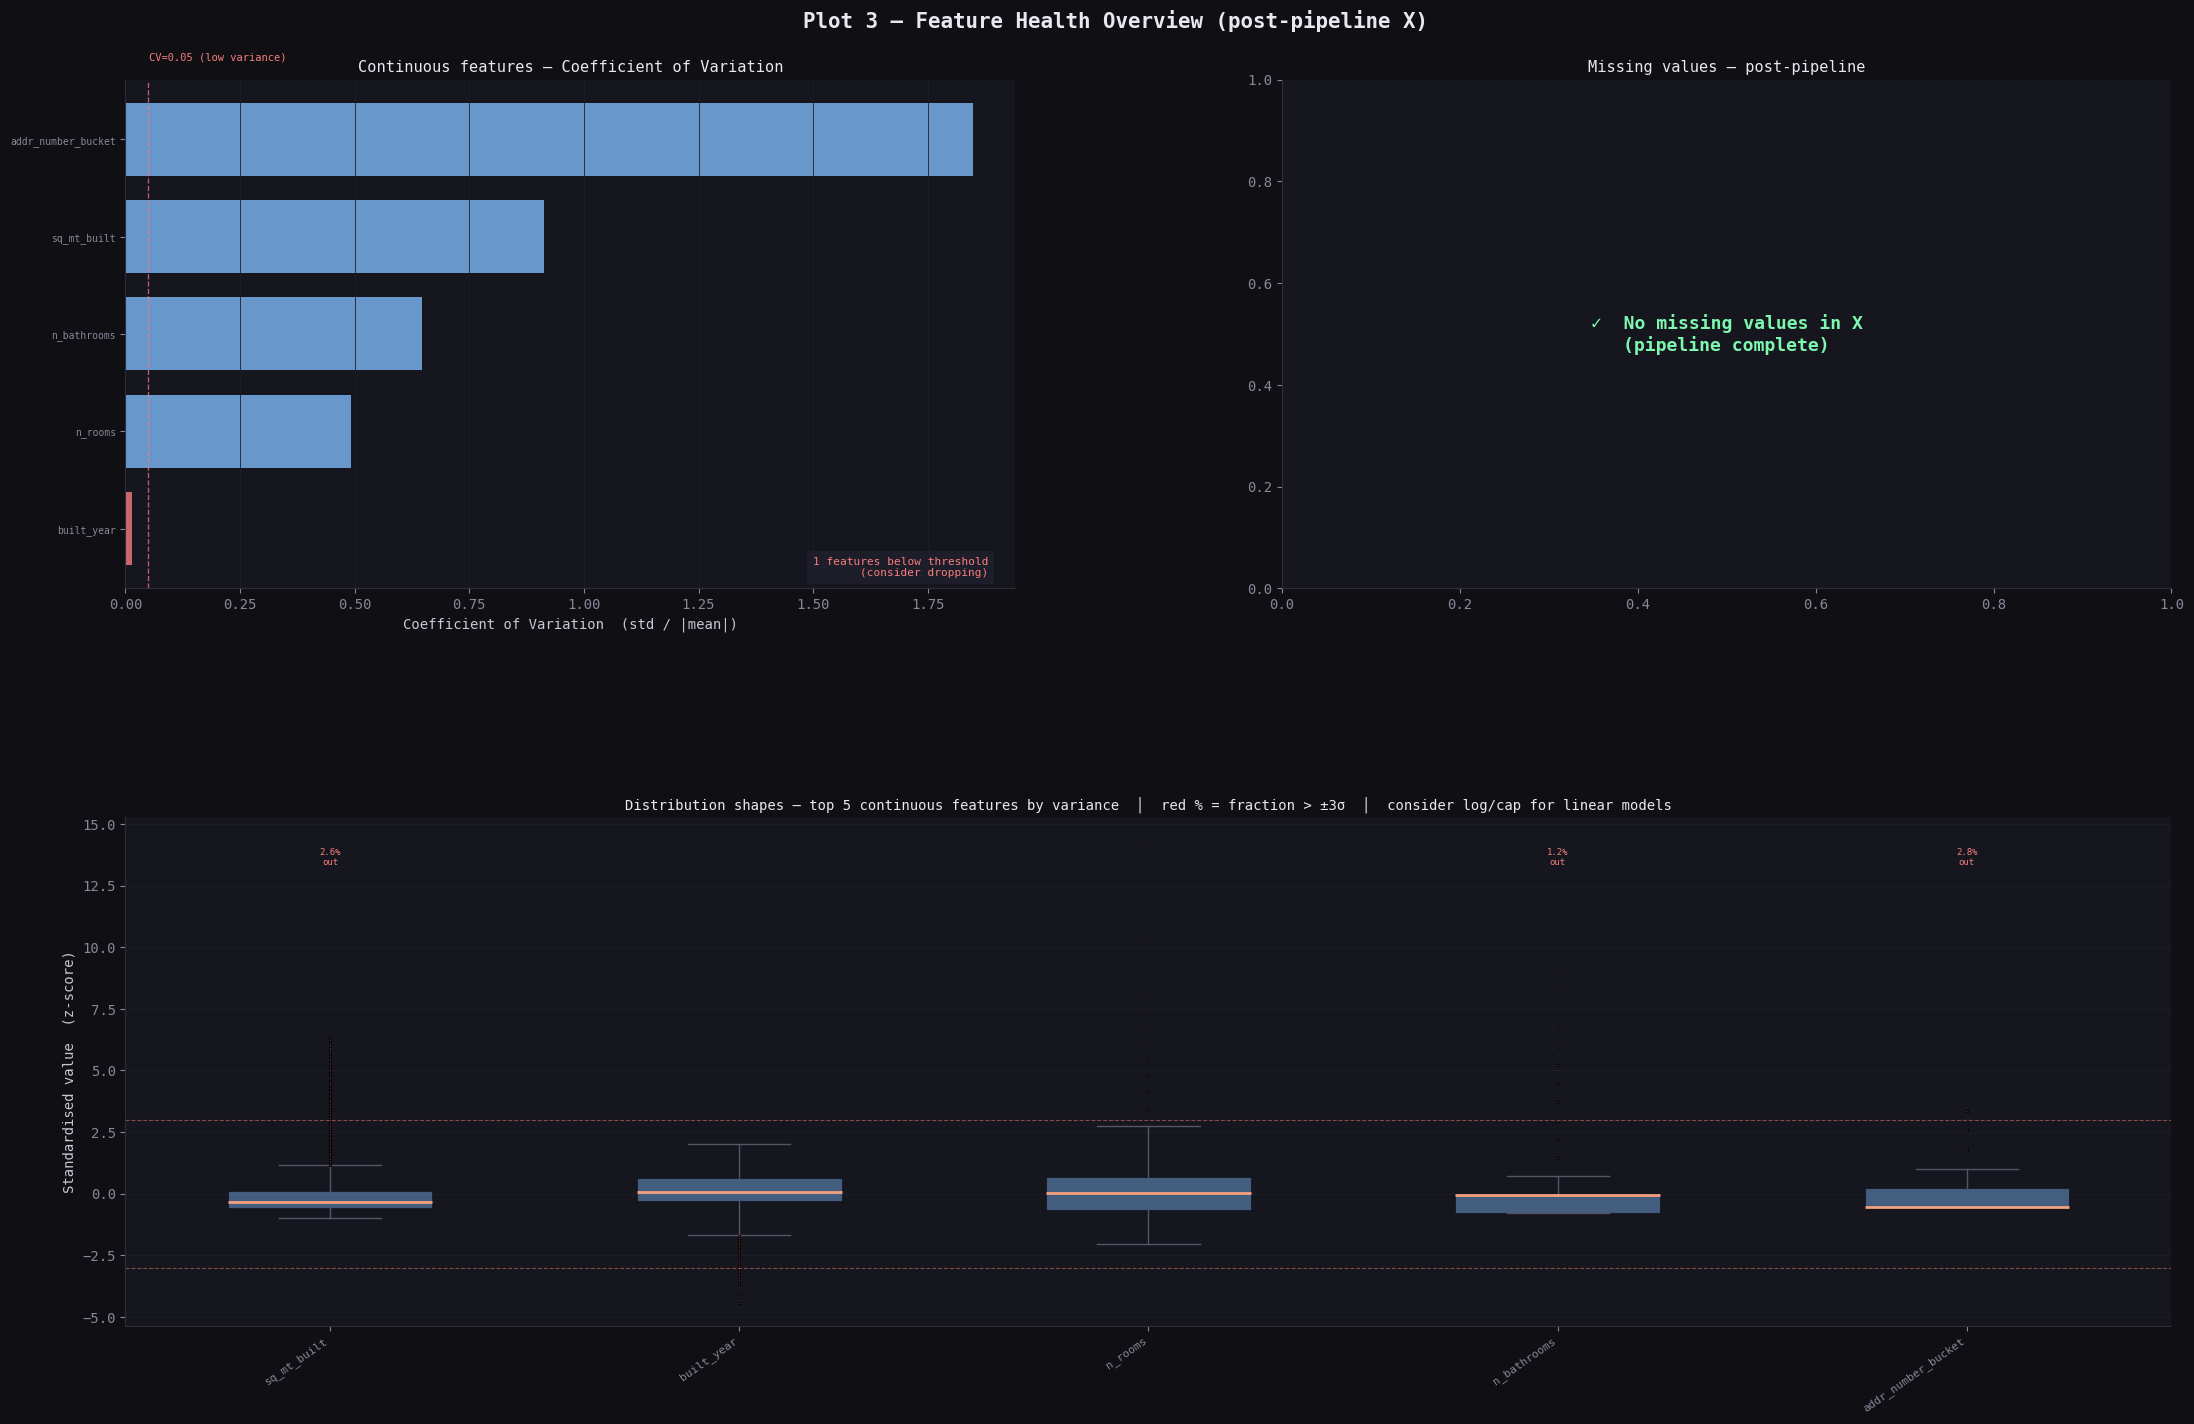

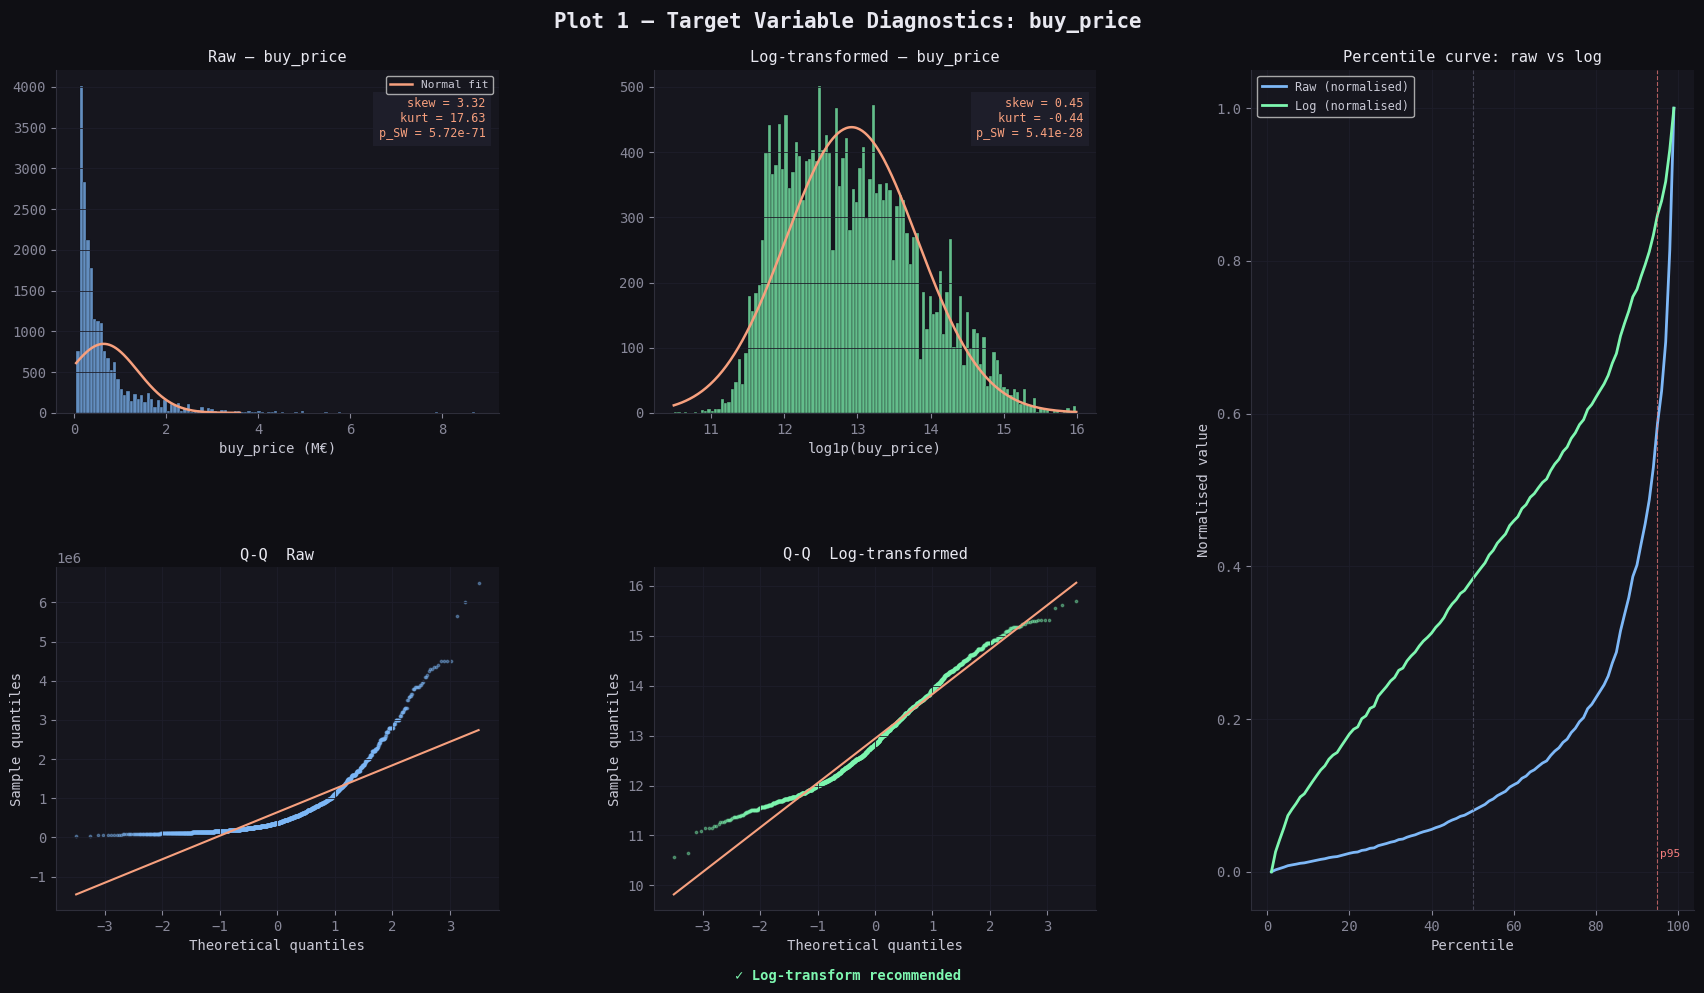

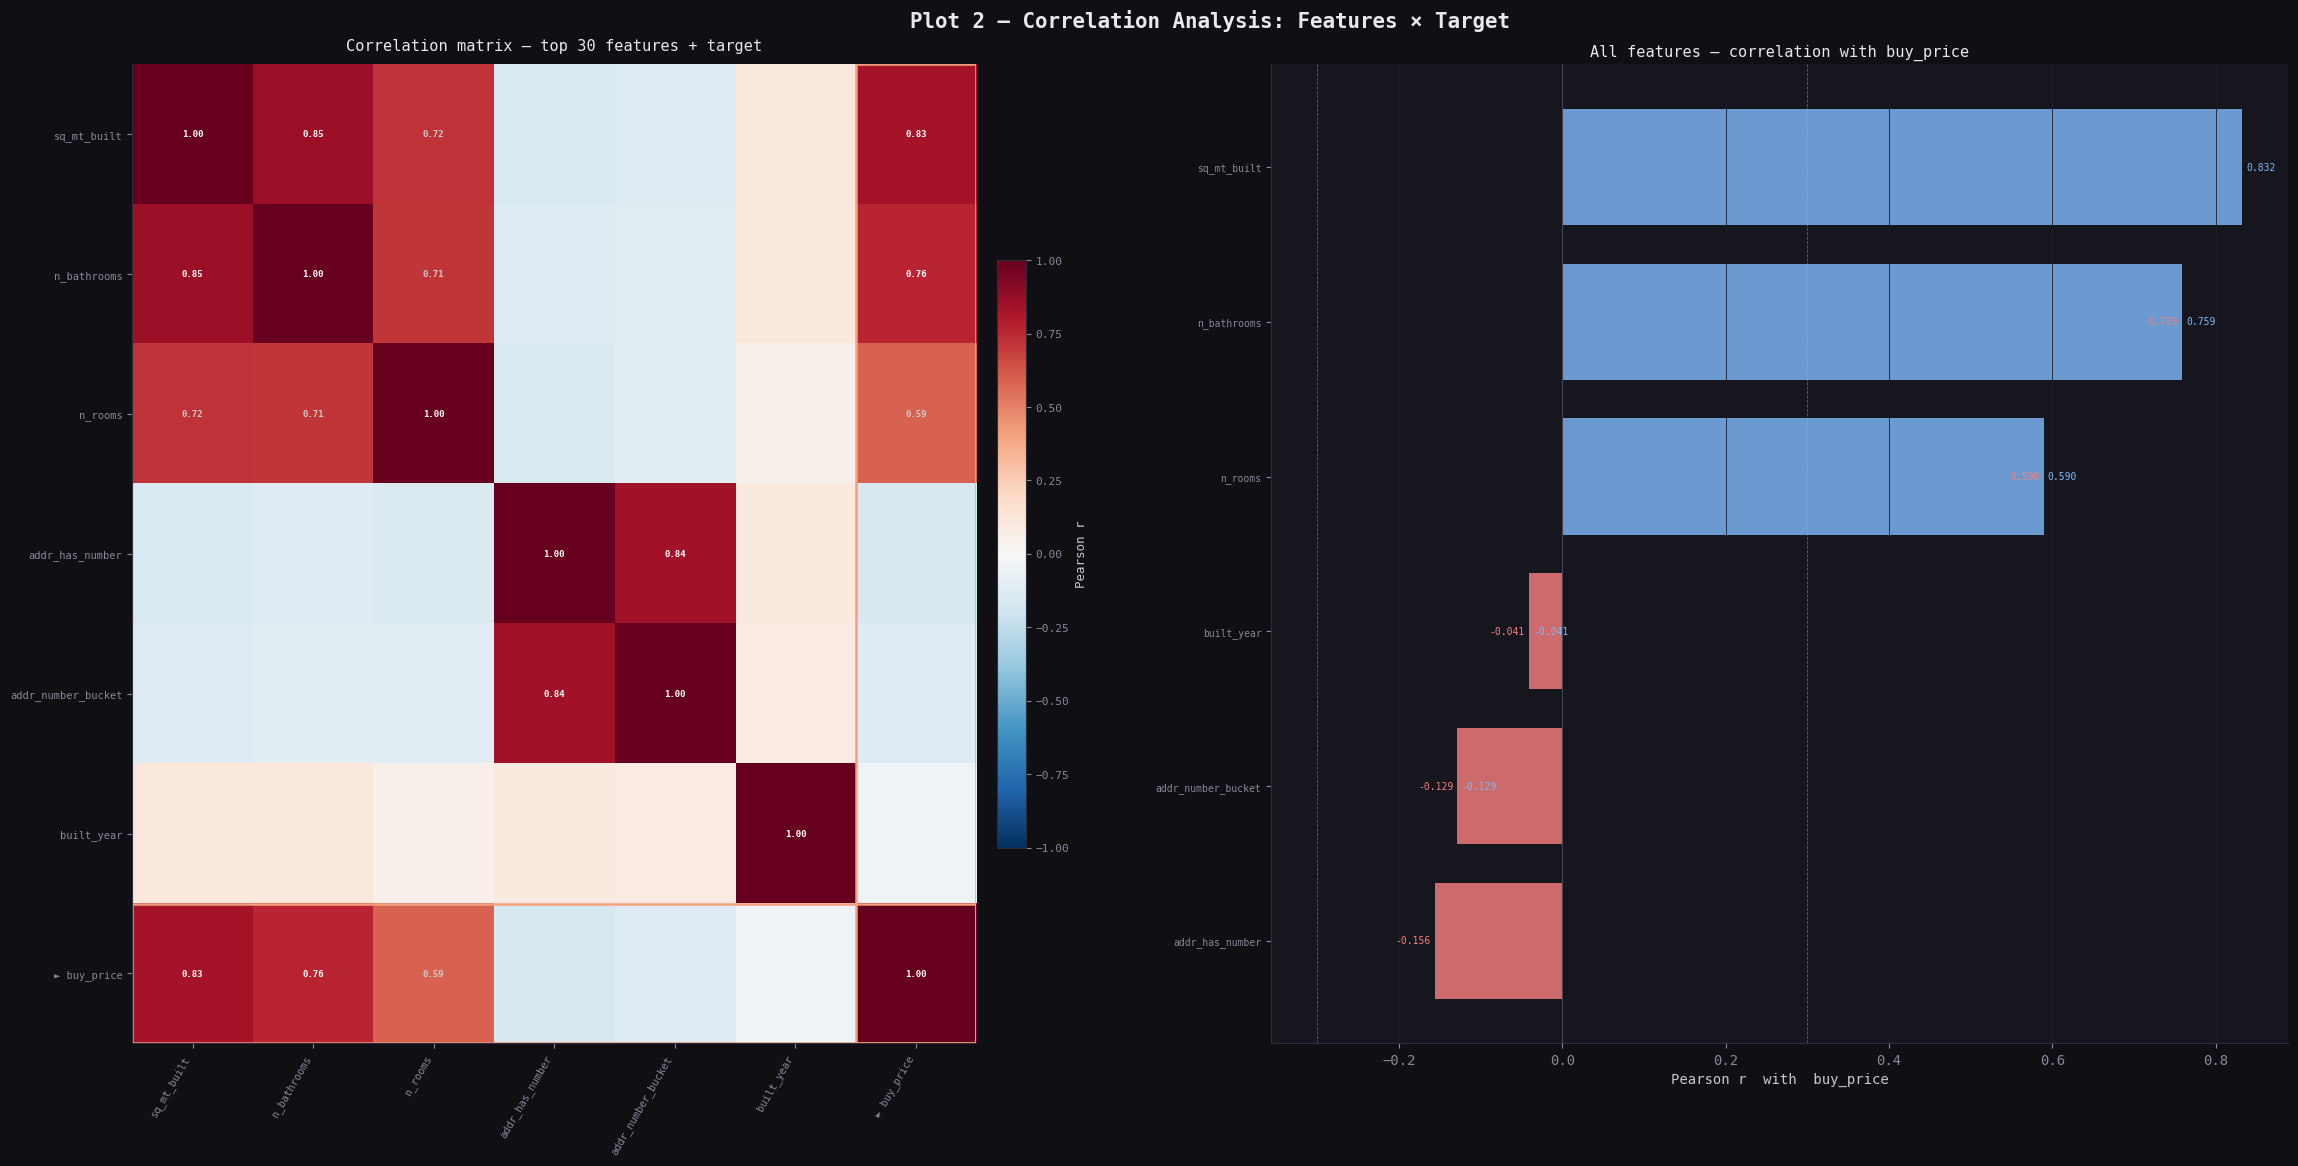

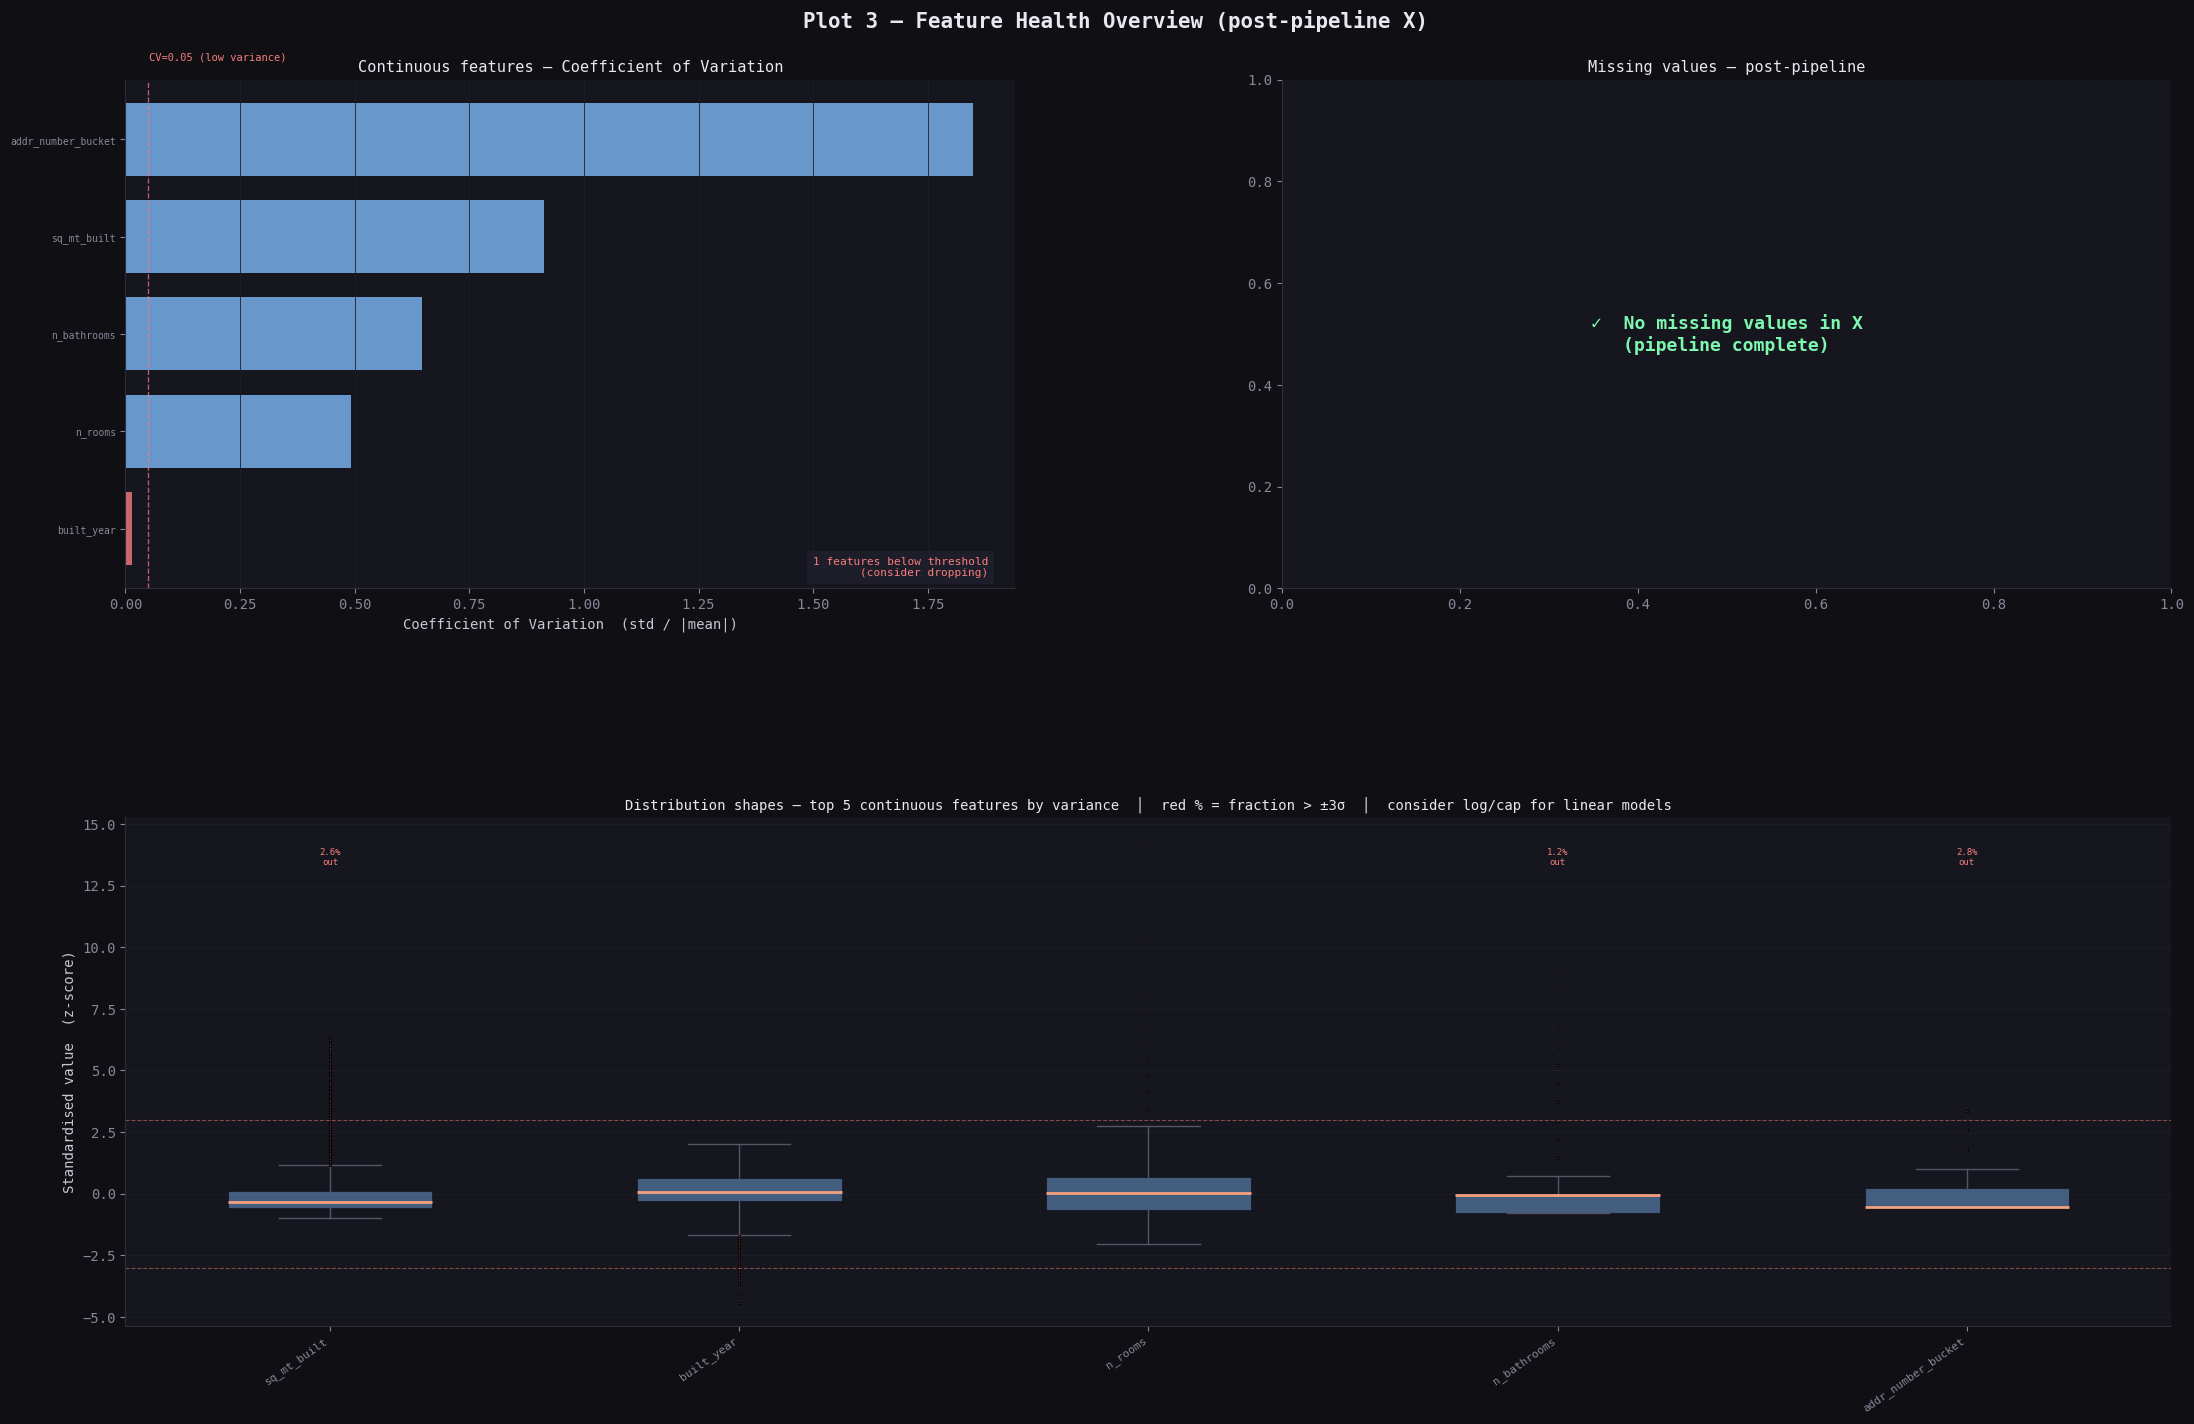

In [417]:
plot_target_distribution(y)
plot_correlation_heatmap(X, y)
plot_feature_overview(X)

In [479]:
"""
Madrid Real Estate — sklearn Feature Transformer Pipeline
==========================================================
Takes the X produced by preprocessing.run_pipeline() and applies
a fully fitted sklearn ColumnTransformer that is safe to use with
cross-validation and hyperparameter search.

Column taxonomy (post-prepare)
-------------------------------
  continuous   : sq_mt_built, n_rooms, n_bathrooms, district_id, …
  binary/dummy : has_ac, has_lift, is_new_development,
                 house_type_id_*, district_id_* (already OHE'd), …
  skewed       : sq_mt_built, n_rooms  (right-tailed → PowerTransformer)

Transformer map
---------------
  continuous (non-skewed)  → SimpleImputer(median) → RobustScaler
  continuous (skewed)      → SimpleImputer(median) → PowerTransformer(yeo-johnson)
                                                    → RobustScaler
  binary / dummy           → SimpleImputer(most_frequent) → pass-through
                             (no scaling — 0/1 is already the right scale)

Extra steps applied to the full matrix after column-wise transforms
-------------------------------------------------------------------
  1. VarianceThreshold   — drops near-constant columns (threshold=0.01)
  2. (optional) PCA      — dimensionality reduction; off by default,
                           activate with build_pipeline(use_pca=True)

Usage
-----
    from preprocessing   import run_pipeline
    from feature_pipeline import build_pipeline, SKEWED_COLS

    import pandas as pd
    df   = pd.read_csv("houses_Madrid.csv")
    X, y = run_pipeline(df)

    # Build + fit in one shot (training set)
    pipe = build_pipeline(X)
    X_train_t = pipe.fit_transform(X_train)
    X_test_t  = pipe.transform(X_test)

    # Inspect what came out
    print(get_feature_names(pipe, X))
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import (RobustScaler, PowerTransformer,
                                     StandardScaler, OneHotEncoder)
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition   import PCA
from sklearn.base            import BaseEstimator, TransformerMixin


# ---------------------------------------------------------------------------
# 0.  Column classification helpers
# ---------------------------------------------------------------------------

# Features with strong right skew in the Madrid dataset.
# PowerTransformer (Yeo-Johnson) makes them more Gaussian before scaling.
# Yeo-Johnson handles zeros and negatives; Box-Cox does not.
SKEWED_COLS = [
    "sq_mt_built",
    "n_rooms",
    "n_bathrooms",
]

def classify_columns(X: pd.DataFrame,
                     skewed_cols: list[str] | None = None,
                     binary_threshold: float = 0.0
                     ) -> tuple[list[str], list[str], list[str]]:
    """
    Split X columns into three buckets:
        skewed_continuous  – numeric, right-skewed (use PowerTransformer)
        continuous         – numeric, roughly symmetric (use RobustScaler)
        binary             – 0/1 or bool columns (pass-through after impute)

    Detection logic
    ---------------
    - A column is *binary* if its non-null unique values are a subset of {0, 1}.
    - A column is *skewed* if it appears in `skewed_cols` OR has skewness > 1.5.
    - Everything else is *continuous*.

    Parameters
    ----------
    X : pd.DataFrame        Feature matrix from run_pipeline().
    skewed_cols : list[str] Extra columns to treat as skewed regardless of
                            measured skewness.  Defaults to SKEWED_COLS.
    binary_threshold : float
        Mean threshold below which a binary column is considered near-zero-
        variance (kept but noted).  Not used for dropping here.

    Returns
    -------
    (skewed_continuous, continuous, binary) : three lists of column names
    """
    if skewed_cols is None:
        skewed_cols = SKEWED_COLS

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    binary, skewed, continuous = [], [], []

    for col in num_cols:
        s = X[col].dropna()
        unique_vals = set(s.unique())

        # Binary / dummy detection
        if unique_vals <= {0, 1, 0.0, 1.0, True, False}:
            binary.append(col)
            continue

        # Skew detection
        col_skew = float(s.skew())
        if col in skewed_cols or abs(col_skew) > 1.5:
            skewed.append(col)
        else:
            continuous.append(col)

    print(f"[classify_columns] skewed={len(skewed)}  "
          f"continuous={len(continuous)}  binary={len(binary)}")
    return skewed, continuous, binary


# ---------------------------------------------------------------------------
# 1.  Custom transformer: ClipOutliers
#     Winsorises extreme values BEFORE scaling so that a single €10M
#     penthouse doesn't dominate the scaler's statistics even after
#     RobustScaler.  Applied only to skewed/continuous columns.
# ---------------------------------------------------------------------------

class ClipOutliers(BaseEstimator, TransformerMixin):
    """
    Winsorise each column at [lower_pct, upper_pct] percentiles.

    Why Winsorising beats dropping
    --------------------------------
    Dropping outlier rows loses information from the entire row.
    Clipping caps the *value* while keeping the observation.
    RobustScaler already reduces outlier influence, but extreme
    values (e.g. sq_mt_built = 5 000) can still shift the
    PowerTransformer's fit on a skewed column.

    Fit stores the per-column clip bounds so test data is clipped
    to training-set percentiles (no leakage).

    Parameters
    ----------
    lower_pct : float, default 1.0    Lower percentile to clip to.
    upper_pct : float, default 99.0   Upper percentile to clip to.
    """
    def __init__(self, lower_pct: float = 1.0, upper_pct: float = 99.0):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct

    def fit(self, X, y=None):
        X = np.array(X, dtype=float)
        self.lower_ = np.nanpercentile(X, self.lower_pct, axis=0)
        self.upper_ = np.nanpercentile(X, self.upper_pct, axis=0)
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float).copy()
        for j in range(X.shape[1]):
            X[:, j] = np.clip(X[:, j], self.lower_[j], self.upper_[j])
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features


# ---------------------------------------------------------------------------
# 2.  Sub-pipelines per column type
# ---------------------------------------------------------------------------

def _skewed_pipe() -> Pipeline:
    """
    Skewed continuous features:
      median impute → clip outliers → Yeo-Johnson → RobustScaler

    Yeo-Johnson before RobustScaler matters because the transformer
    works best on raw values; scaling first compresses the distribution
    in a way that can interfere with the transformation.
    """
    return Pipeline([
        ("imputer",   SimpleImputer(strategy="median")),
        ("clip",      ClipOutliers(lower_pct=1.0, upper_pct=99.0)),
        ("power",     PowerTransformer(method="yeo-johnson", standardize=False)),
        ("scaler",    RobustScaler()),
    ])


def _continuous_pipe() -> Pipeline:
    """
    Symmetric / mildly skewed continuous features:
      median impute → clip outliers → RobustScaler

    RobustScaler uses median and IQR instead of mean/std, so it is
    naturally resistant to outliers without needing PowerTransformer.
    StandardScaler is NOT used here because Madrid price-related
    features (sq_mt, district_id) have meaningful outliers that
    shouldn't shrink the scale.
    """
    return Pipeline([
        ("imputer",  SimpleImputer(strategy="median")),
        ("clip",     ClipOutliers(lower_pct=1.0, upper_pct=99.0)),
        ("scaler",   RobustScaler()),
    ])


def _binary_pipe() -> Pipeline:
    """
    Binary / dummy features (0/1):
      most_frequent impute → pass-through (no scaling)

    Scaling binary features to different ranges than [0,1] breaks
    their interpretability and can confuse tree-based models.
    For linear models, the coefficient already absorbs the scale.
    """
    return Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])


# ---------------------------------------------------------------------------
# 3.  build_pipeline — assembles ColumnTransformer + post-steps
# ---------------------------------------------------------------------------

def build_pipeline(X: pd.DataFrame,
                   skewed_cols:      list[str] | None = None,
                   use_pca:          bool             = False,
                   pca_components:   int | float      = 0.95,
                   variance_thresh:  float            = 0.01,
                   ) -> Pipeline:
    """
    Build a fully sklearn-compatible Pipeline for the Madrid X matrix.

    Architecture
    ------------
    Step 1 — ColumnTransformer
        Applies the three sub-pipelines in parallel by column group:
          • skewed_continuous  → ClipOutliers + PowerTransformer + RobustScaler
          • continuous         → ClipOutliers + RobustScaler
          • binary/dummy       → most_frequent impute, no scale

    Step 2 — VarianceThreshold(threshold=variance_thresh)
        Removes columns whose variance falls below the threshold after
        transformation.  Binary columns with a 99/1 split have very low
        variance (~0.0099) and add noise without signal.
        Default: 0.01  ≈ a feature that is True less than ~1% of the time.

    Step 3 (optional) — PCA
        Off by default.  Enable with use_pca=True.
        pca_components=0.95 retains enough components to explain 95% of
        total variance — useful as a regularisation step before linear
        models (Ridge, Lasso) to address any remaining collinearity.
        NOT recommended before tree-based models (XGBoost, LightGBM,
        RandomForest) — they handle correlated features natively and PCA
        destroys feature interpretability.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix from run_pipeline().  Used to detect column types;
        NOT fitted here (call pipe.fit(X_train) separately).
    skewed_cols : list[str] or None
        Override the default skewed column list.
    use_pca : bool, default False
        Append a PCA step after VarianceThreshold.
    pca_components : int or float, default 0.95
        Passed directly to PCA(n_components=...).
    variance_thresh : float, default 0.01
        Threshold for VarianceThreshold.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Unfitted pipeline.  Call .fit_transform(X_train) or
        .fit(X_train).transform(X_test).
    """
    skewed, continuous, binary = classify_columns(X, skewed_cols=skewed_cols)

    # Log what we found
    print(f"\n[build_pipeline] Column assignment:")
    print(f"  Skewed continuous ({len(skewed)}):    {skewed}")
    print(f"  Continuous        ({len(continuous)}): {continuous[:8]}{'…' if len(continuous)>8 else ''}")
    print(f"  Binary/dummy      ({len(binary)}):   (first 8) {binary[:8]}{'…' if len(binary)>8 else ''}")

    # Guard: only include groups that have at least one column
    transformers = []
    if skewed:
        transformers.append(("skewed",     _skewed_pipe(),     skewed))
    if continuous:
        transformers.append(("continuous", _continuous_pipe(), continuous))
    if binary:
        transformers.append(("binary",     _binary_pipe(),     binary))

    col_transformer = ColumnTransformer(
        transformers=transformers,
        remainder="drop",           # drop any column not assigned above
        verbose_feature_names_out=True,
    )

    steps = [
        ("col_transform",   col_transformer),
        ("variance_filter", VarianceThreshold(threshold=variance_thresh)),
    ]

    if use_pca:
        steps.append(("pca", PCA(n_components=pca_components, random_state=42)))
        print(f"  PCA enabled: retaining {pca_components} "
              f"{'components' if isinstance(pca_components, int) else 'variance'}")
    else:
        print("  PCA disabled (default).  Enable with use_pca=True for linear models.")

    pipe = Pipeline(steps)
    print(f"\n[build_pipeline] Pipeline assembled with {len(steps)} steps.")
    return pipe


# ---------------------------------------------------------------------------
# 4.  get_feature_names — recover column names after ColumnTransformer
# ---------------------------------------------------------------------------

def get_feature_names(pipe: Pipeline, X: pd.DataFrame) -> list[str]:
    """
    Return the feature names that survive the full pipeline,
    accounting for VarianceThreshold dropping columns.

    Parameters
    ----------
    pipe : fitted Pipeline from build_pipeline()
    X    : the original X DataFrame (before transform)

    Returns
    -------
    list[str]  Feature names in the same order as pipe.transform(X) columns.
    """
    ct   = pipe.named_steps["col_transform"]
    vt   = pipe.named_steps["variance_filter"]

    # sklearn >= 1.0 exposes get_feature_names_out on ColumnTransformer
    try:
        names_after_ct = list(ct.get_feature_names_out())
    except AttributeError:
        # fallback: flatten manually
        names_after_ct = []
        for name, trans, cols in ct.transformers_:
            if hasattr(trans, "get_feature_names_out"):
                names_after_ct.extend(trans.get_feature_names_out(cols))
            else:
                names_after_ct.extend(cols)

    # VarianceThreshold mask
    mask           = vt.get_support()
    names_final    = [n for n, keep in zip(names_after_ct, mask) if keep]

    # PCA replaces names with component indices
    if "pca" in pipe.named_steps:
        n_comp      = pipe.named_steps["pca"].n_components_
        names_final = [f"PC_{i+1}" for i in range(n_comp)]

    return names_final

In [480]:
from sklearn.model_selection import train_test_split

y = np.log1p(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe     = build_pipeline(X_train)            # detect column types
X_prepared_train   = pipe.fit_transform(X_train)        # fit on train only
X_prepared_test   = pipe.transform(X_test)             # apply to test (no leakage)

names    = get_feature_names(pipe, X_train)   # recover column name

[classify_columns] skewed=4  continuous=1  binary=1

[build_pipeline] Column assignment:
  Skewed continuous (4):    ['sq_mt_built', 'n_rooms', 'n_bathrooms', 'addr_number_bucket']
  Continuous        (1): ['built_year']
  Binary/dummy      (1):   (first 8) ['addr_has_number']
  PCA disabled (default).  Enable with use_pca=True for linear models.

[build_pipeline] Pipeline assembled with 2 steps.


In [481]:
X_prepared_train.shape

(17275, 6)

In [482]:
y.head()

0    11.350418
1    11.774528
2    11.879289
3    11.607335
4    12.468441
Name: buy_price, dtype: float64

In [423]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators      = 10,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,       # L1 — sparse features
    reg_lambda        = 1.0,       # L2 — default
    early_stopping_rounds = 50,
    eval_metric       = "rmse",
    random_state      = 42,
    n_jobs            = -1,
)

In [ ]:
model.fit(
    X_prepared_train, y_train,
    eval_set=[(X_prepared_test, y_test)],
    verbose=100,
)

[0]	validation_0-rmse:0.87197
[9]	validation_0-rmse:0.63789


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [424]:
from sklearn import metrics
from sklearn import model_selection
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import math

scores=['r2','neg_mean_absolute_error','neg_mean_squared_error']
for model in [DecisionTreeRegressor, RandomForestRegressor]:
    cls=model()
    kfold=model_selection.KFold(n_splits=10)
    s=model_selection.cross_validate(cls, X_train,y_train,scoring=scores,cv=kfold)
    mse=s['test_neg_mean_squared_error'].mean()*-1
    rmse=math.sqrt(mse)
    print(
        f"{model.__name__:22} Fit Time: "
        f"{s['fit_time'].mean():.3f}s  R2: "
        f"{s['test_r2'].mean():.3f}  MAE: "
        f"{s['test_neg_mean_absolute_error'].mean()*-1:.3f}  RMSE: "
        f"{rmse:.3f}"
    )

DecisionTreeRegressor  Fit Time: 0.268s  R2: 0.886  MAE: 0.209  RMSE: 0.303
RandomForestRegressor  Fit Time: 16.285s  R2: 0.938  MAE: 0.159  RMSE: 0.223


In [ ]:
import regex as re
train_x = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
#missing vals included
for model in [xgb.XGBRegressor, lgb.LGBMRegressor]:
    if model == lgb.LGBMRegressor:
        cls=model(force_row_wise=True, verbose=-1)
    else:
        cls=model()
    kfold=model_selection.KFold(n_splits=10)
    s=model_selection.cross_validate(cls,train_x,y_train,scoring=scores,cv=kfold)
    mse=s['test_neg_mean_squared_error'].mean()*-1
    rmse=math.sqrt(mse)
    print(
        f"{model.__name__:22} Fit Time: "
        f"{s['fit_time'].mean():.3f}s  R2: "
        f"{s['test_r2'].mean():.3f}  MAE: "
        f"{s['test_neg_mean_absolute_error'].mean()*-1:.3f}  RMSE: "
        f"{rmse:.3f}"
    )

XGBRegressor           Fit Time: 0.202s  R2: 0.944  MAE: 0.160  RMSE: 0.213
LGBMRegressor          Fit Time: 0.361s  R2: 0.943  MAE: 0.162  RMSE: 0.215


In [ ]:
X_train.head()

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_rent_price_known,is_renewal_needed,has_lift,is_exterior,has_parking,addr_has_number,...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
17739,127.0,4,2.0,True,False,False,True,True,True,0,...,True,False,False,False,False,False,False,False,False,False
17096,80.0,3,1.0,True,False,False,True,True,True,0,...,True,False,False,False,False,False,False,False,False,False
17360,160.0,3,2.0,True,False,False,True,True,False,0,...,False,False,False,False,False,True,False,False,False,False
18013,162.0,5,2.0,True,False,False,True,True,False,0,...,False,False,False,False,False,True,False,False,False,False
7274,508.0,6,5.0,True,False,False,True,True,True,0,...,False,False,False,False,False,True,False,False,False,False


In [483]:
# ── 1. Feature importance — what is the model actually using? ────────────
importances = pd.Series(
    RandomForestRegressor().fit(X_train, y_train).feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features by importance:")
print(importances.head(15).to_string())

# ── 2. Single-feature R² — find the column that alone explains ~0.999 ───
from sklearn.tree import DecisionTreeRegressor

single_r2 = {}
for col in X_train.columns:
    r2 = DecisionTreeRegressor().fit(
        X_train[[col]], y_train
    ).score(X_train[[col]], y_train)
    single_r2[col] = r2

single = pd.Series(single_r2).sort_values(ascending=False)
print("\nTop 10 single-feature train R²:")
print(single.head(10).to_string())

# ── 3. Pearson correlation with target ───────────────────────────────────
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("\nTop 10 correlations with y_train:")
print(corr.head(10).to_string())

Top 15 features by importance:
sq_mt_built       0.774305
built_year        0.052509
n_bathrooms       0.020986
district_id_5     0.012844
district_id_13    0.009875
n_rooms           0.007523
has_parking       0.005666
has_lift          0.005421
district_id_18    0.005271
district_id_3     0.005056
district_id_20    0.003678
district_id_1     0.003486
district_id_17    0.003378
district_id_19    0.003295
district_id_14    0.003166

Top 10 single-feature train R²:
sq_mt_built                                 0.782878
n_bathrooms                                 0.671230
n_rooms                                     0.436348
built_year                                  0.258962
has_parking                                 0.166682
house_type_id_HouseType 2: Casa o chalet    0.152973
house_type_id_HouseType 1: Pisos            0.105361
has_lift                                    0.093103
addr_street_type_Other                      0.079096
district_id_13                              0.073025




───────────────────────────────────────────────────────────────────────────────────────────────
Model                       Train R²     CV R²       Gap        MAE €      MedAE €    MAPE %  Verdict
───────────────────────────────────────────────────────────────────────────────────────────────
DecisionTreeRegressor          0.859     0.850     0.009      164,507       76,583    28.18%  ✓ OK
RandomForestRegressor          0.946     0.927     0.019      126,207       46,092    18.50%  ✓ OK
───────────────────────────────────────────────────────────────────────────────────────────────

Computing learning curves …
Computing validation curves …


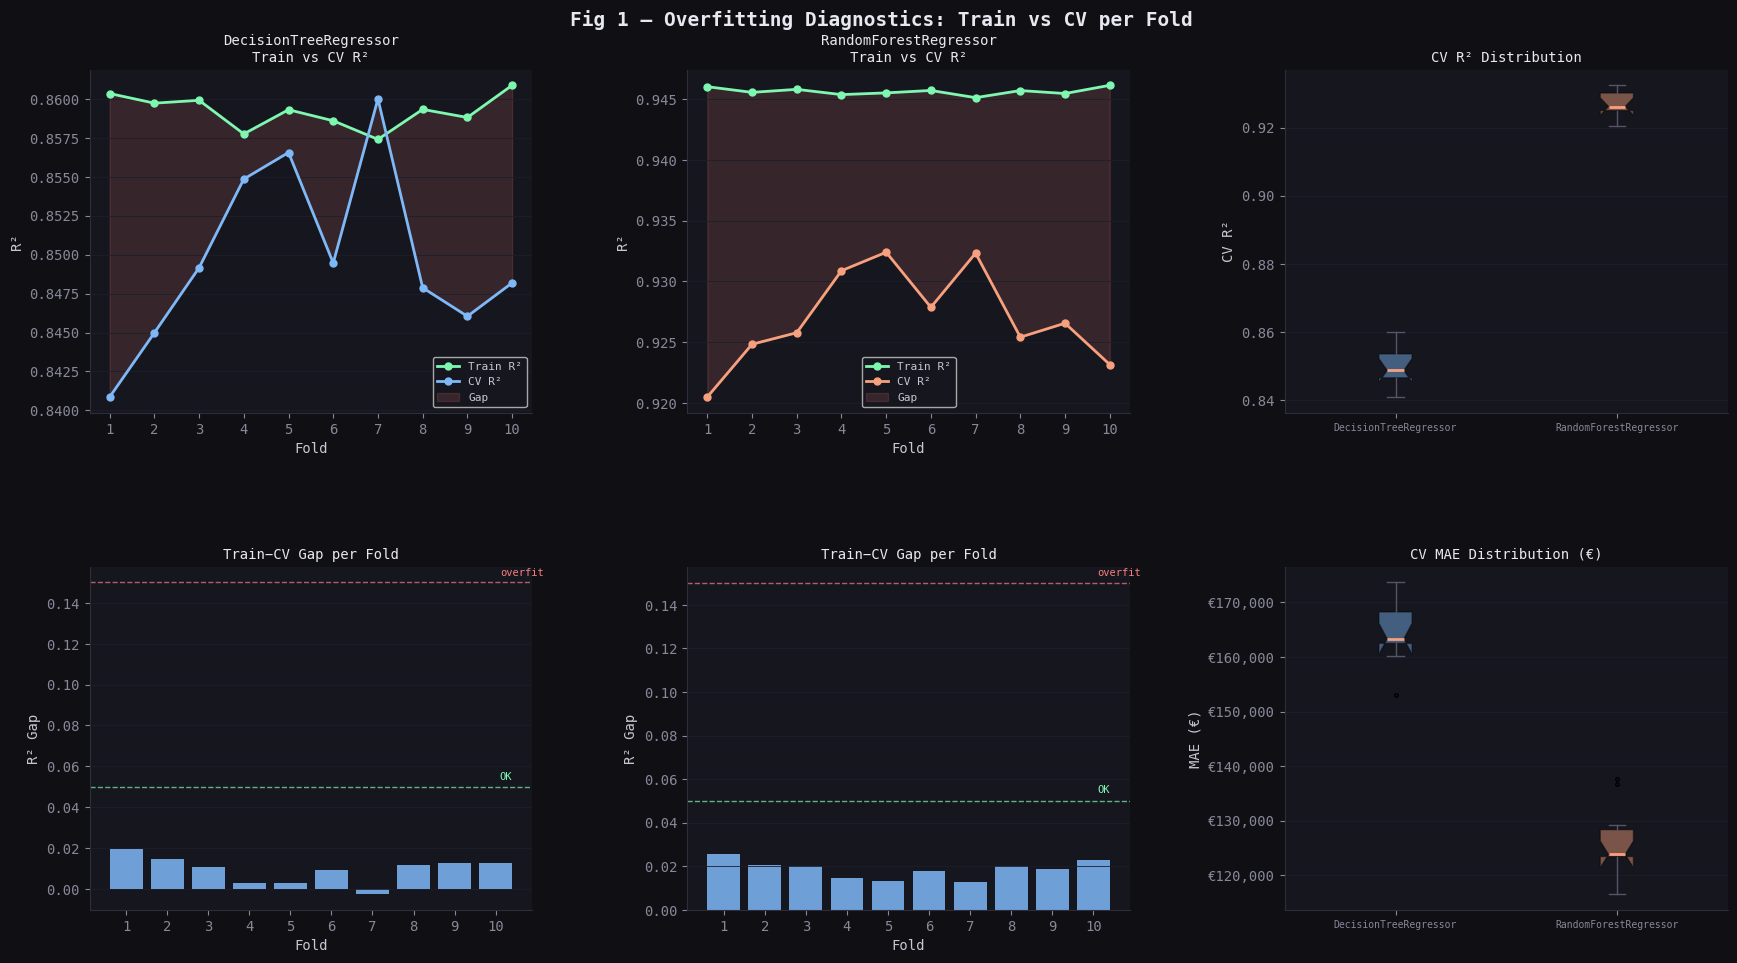

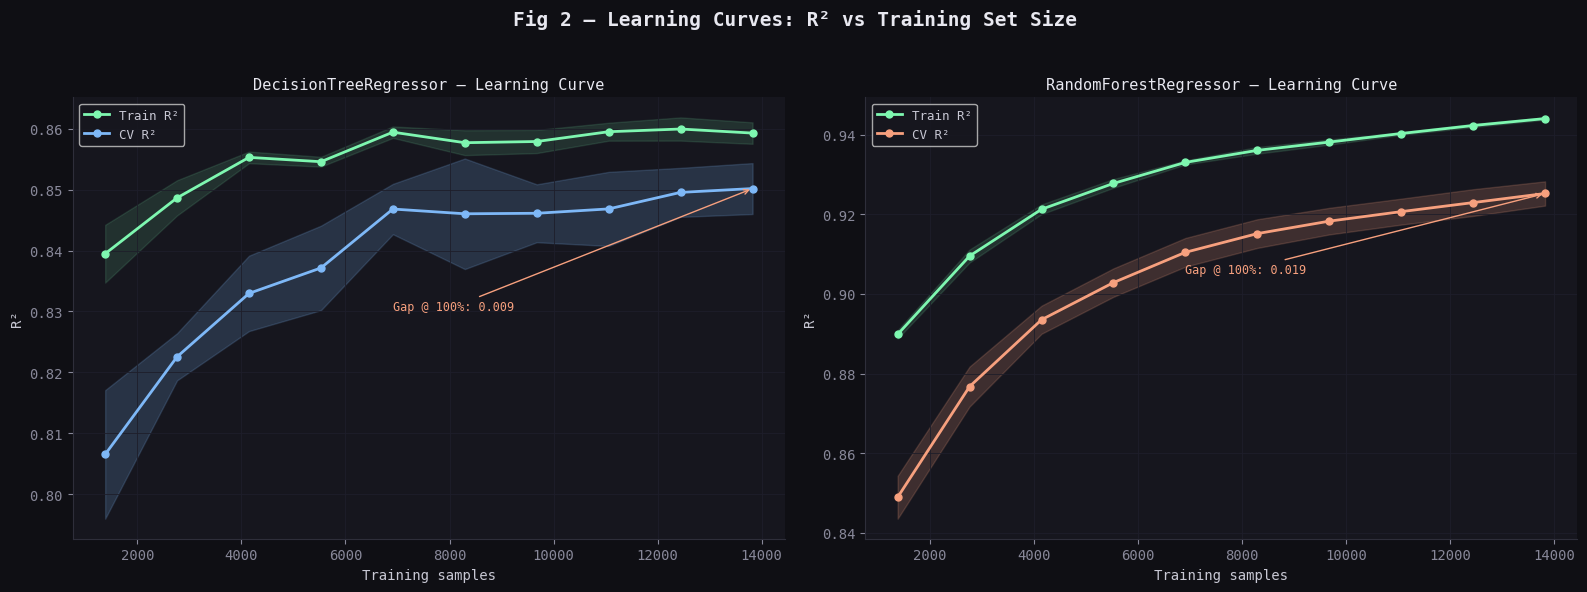

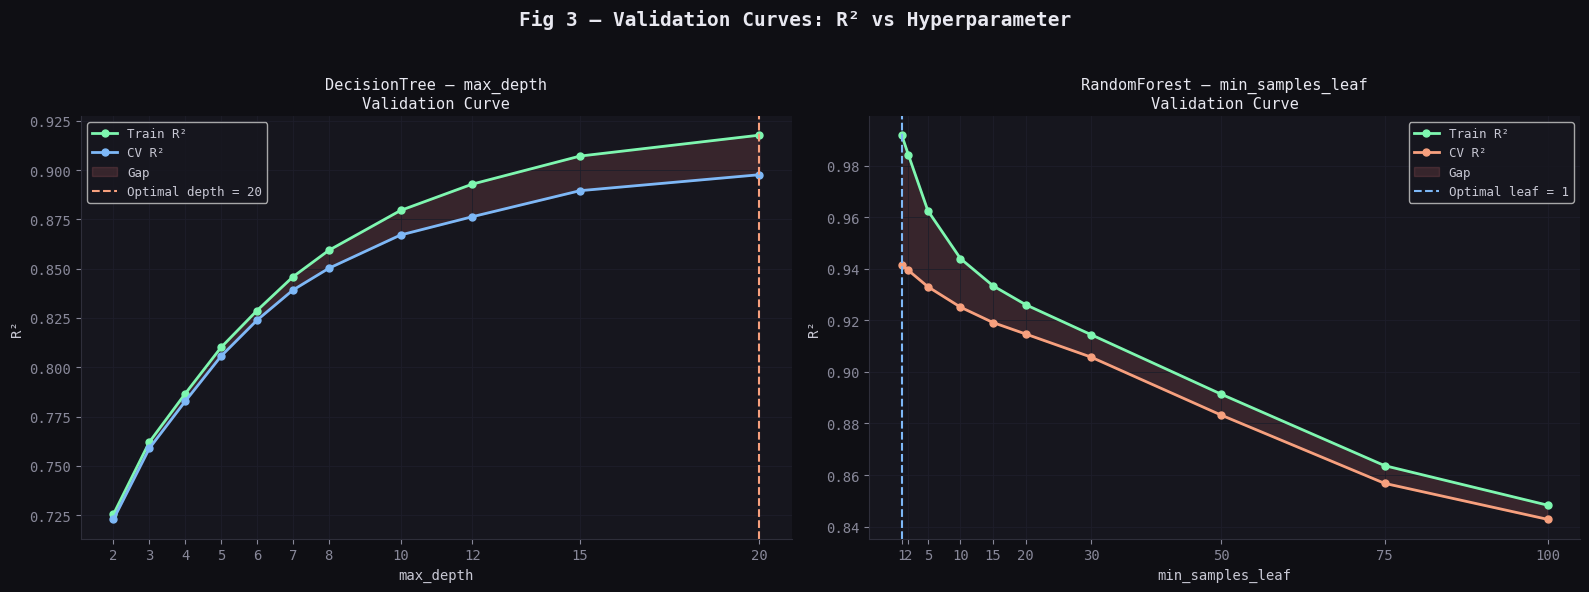


Saved → fig1_overfit_folds.png
Saved → fig2_learning_curves.png
Saved → fig3_validation_curves.png

Validation curve optima:
  DecisionTree  best max_depth       = 20
  RandomForest  best min_samples_leaf = 1


In [ ]:
"""
Overfitting Diagnostics — Visual + Numeric
Figures
-------
  Fig 1 — Train/CV R² per fold + Gap bars + box-plots  (existing)
  Fig 2 — Learning curves   : score vs training set size
  Fig 3 — Validation curves : score vs key hyperparameter per model
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn import model_selection
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, mean_absolute_error, median_absolute_error
from sklearn.tree    import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ── Custom scorers — back-transform log predictions to euros before scoring ──
# cross_validate receives log-scale y; these scorers undo the transform so
# MAE, MedAE, MAPE are reported in euros — the only interpretable unit.
def _mae_euros(y_true, y_pred):
    return mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

def _medae_euros(y_true, y_pred):
    return median_absolute_error(np.expm1(y_true), np.expm1(y_pred))

def _mape_euros(y_true, y_pred):
    t, p = np.expm1(y_true), np.expm1(y_pred)
    return np.mean(np.abs((t - p) / t)) * 100

scorer_mae   = make_scorer(_mae_euros,   greater_is_better=False)
scorer_medae = make_scorer(_medae_euros, greater_is_better=False)
scorer_mape  = make_scorer(_mape_euros,  greater_is_better=False)

# ── Models ───────────────────────────────────────────────────────────────────
MODELS = [
    DecisionTreeRegressor(
        max_depth         = 8,
        min_samples_leaf  = 20,
        min_samples_split = 40,
    ),
    RandomForestRegressor(
        n_estimators      = 300,
        max_depth         = None,
        min_samples_leaf  = 10,
        max_features      = None,
        random_state      = 42,
    ),
]
SCORES = {
    "r2":    "r2",
    "mae":   scorer_mae,      # €  — primary metric
    "medae": scorer_medae,    # €  — robust to luxury outliers
    "mape":  scorer_mape,     # %  — relative, segment-comparable
}
KFOLD  = model_selection.KFold(n_splits=10, shuffle=True, random_state=42)
CV5    = model_selection.KFold(n_splits=5,  shuffle=True, random_state=42)
COLORS = ["#7eb8f7", "#f7a07e"]

plt.rcParams.update({
    "figure.facecolor": "#0f0f14", "axes.facecolor":  "#16161e",
    "axes.edgecolor":   "#2e2e3a", "axes.labelcolor": "#c8c8d4",
    "axes.titlecolor":  "#e8e8f0", "xtick.color":     "#888899",
    "ytick.color":      "#888899", "text.color":      "#c8c8d4",
    "grid.color":       "#1e1e2a", "font.family":     "monospace",
    "axes.spines.top":  False,     "axes.spines.right": False,
})

# ── 1. Numeric table ─────────────────────────────────────────────────────────
print(f"\n{'─'*95}")
print(f"{'Model':<26} {'Train R²':>9} {'CV R²':>9} {'Gap':>9} "
      f"{'MAE €':>12} {'MedAE €':>12} {'MAPE %':>9}  Verdict")
print(f"{'─'*95}")

results = {}
for model, color in zip(MODELS, COLORS):
    cv = model_selection.cross_validate(
        model, X_train, y_train,
        scoring=SCORES, cv=KFOLD,
        return_train_score=True,
    )
    train_r2 = cv["train_r2"].mean()
    cv_r2    = cv["test_r2"].mean()
    gap      = train_r2 - cv_r2
    mae      = cv["test_mae"].mean()   * -1   # €
    medae    = cv["test_medae"].mean() * -1   # €
    mape     = cv["test_mape"].mean()  * -1   # %

    if gap > 0.15:   verdict = "⚠ OVERFIT"
    elif gap > 0.05: verdict = "~ mild overfit"
    else:            verdict = "✓ OK"

    name = model.__class__.__name__
    print(f"{name:<26} {train_r2:>9.3f} {cv_r2:>9.3f} "
          f"{gap:>9.3f} {mae:>12,.0f} {medae:>12,.0f} {mape:>8.2f}%  {verdict}")

    results[name] = {
        "model":           model,
        "train_r2_folds":  cv["train_r2"],
        "cv_r2_folds":     cv["test_r2"],
        "cv_mae_folds":    cv["test_mae"]   * -1,   # € per fold
        "cv_medae_folds":  cv["test_medae"] * -1,   # € per fold
        "cv_mape_folds":   cv["test_mape"]  * -1,   # % per fold
        "color":           color,
    }
print(f"{'─'*95}\n")


# ════════════════════════════════════════════════════════════════════════════
# FIG 1 — fold-level diagnostics
# ════════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(18, 10), facecolor="#0f0f14")
fig1.suptitle("Fig 1 — Overfitting Diagnostics: Train vs CV per Fold",
              fontsize=14, fontweight="bold", color="#e8e8f0")

gs1   = gridspec.GridSpec(2, 3, figure=fig1,
                          hspace=0.45, wspace=0.35,
                          left=0.06, right=0.97, top=0.92, bottom=0.08)
folds = np.arange(1, 11)

for col_idx, (name, res) in enumerate(results.items()):
    c     = res["color"]
    tr    = res["train_r2_folds"]
    cv_r2 = res["cv_r2_folds"]
    gap   = tr - cv_r2

    ax = fig1.add_subplot(gs1[0, col_idx])
    ax.plot(folds, tr,    "o-", color="#7ef7b0", lw=2, label="Train R²", ms=5)
    ax.plot(folds, cv_r2, "o-", color=c,         lw=2, label="CV R²",    ms=5)
    ax.fill_between(folds, tr, cv_r2, alpha=0.15, color="#f77e7e", label="Gap")
    ax.set_title(f"{name}\nTrain vs CV R²", fontsize=10)
    ax.set_xlabel("Fold"); ax.set_ylabel("R²")
    ax.set_xticks(folds); ax.legend(fontsize=8); ax.grid(True, axis="y")

    ax2 = fig1.add_subplot(gs1[1, col_idx])
    bar_colors = ["#f77e7e" if g > 0.15 else "#7eb8f7" for g in gap]
    ax2.bar(folds, gap, color=bar_colors, alpha=0.85, edgecolor="none")
    ax2.axhline(0.15, color="#f77e7e", ls="--", lw=1, alpha=0.7)
    ax2.axhline(0.05, color="#7ef7b0", ls="--", lw=1, alpha=0.7)
    ax2.text(10.1, 0.155, "overfit", color="#f77e7e", fontsize=7.5, va="center")
    ax2.text(10.1, 0.055, "OK",      color="#7ef7b0", fontsize=7.5, va="center")
    ax2.set_title("Train−CV Gap per Fold", fontsize=10)
    ax2.set_xlabel("Fold"); ax2.set_ylabel("R² Gap")
    ax2.set_xticks(folds); ax2.grid(True, axis="y")

ax3 = fig1.add_subplot(gs1[0, 2])
bp  = ax3.boxplot([r["cv_r2_folds"] for r in results.values()],
                  patch_artist=True, notch=True,
                  medianprops=dict(color="#f7a07e", lw=2),
                  whiskerprops=dict(color="#555566"),
                  capprops=dict(color="#555566"),
                  flierprops=dict(marker=".", color="#f77e7e", ms=5))
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.45)
ax3.set_xticks([1, 2]); ax3.set_xticklabels(list(results), fontsize=7)
ax3.set_ylabel("CV R²"); ax3.set_title("CV R² Distribution", fontsize=10)
ax3.grid(True, axis="y")

ax4 = fig1.add_subplot(gs1[1, 2])
bp2 = ax4.boxplot([r["cv_mae_folds"] for r in results.values()],
                  patch_artist=True, notch=True,
                  medianprops=dict(color="#f7a07e", lw=2),
                  whiskerprops=dict(color="#555566"),
                  capprops=dict(color="#555566"),
                  flierprops=dict(marker=".", color="#f77e7e", ms=5))
for patch, c in zip(bp2["boxes"], COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.45)
ax4.set_xticks([1, 2]); ax4.set_xticklabels(list(results), fontsize=7)
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"\u20ac{x:,.0f}"))
ax4.set_ylabel("MAE (\u20ac)"); ax4.set_title("CV MAE Distribution (\u20ac)", fontsize=10)
ax4.grid(True, axis="y")

fig1.savefig("fig1_overfit_folds.png", dpi=150, bbox_inches="tight",
             facecolor=fig1.get_facecolor())


# ════════════════════════════════════════════════════════════════════════════
# FIG 2 — Learning Curves
# ─────────────────────────────────────────────────────────────────────────
# X-axis : training samples used (10 % → 100 % of X_train)
# Y-axis : R²
#
# How to read it
# ──────────────
# Both lines high & converging  → good fit, more data won't help much
# Train high, CV low, gap stays wide at 100%  → overfit; add regularisation
# Both lines low & converging   → underfit; need more/better features
# CV still rising at 100%       → model would benefit from more data
# ════════════════════════════════════════════════════════════════════════════
print("Computing learning curves …")

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f0f14")
fig2.suptitle("Fig 2 — Learning Curves: R² vs Training Set Size",
              fontsize=14, fontweight="bold", color="#e8e8f0")

train_sizes = np.linspace(0.10, 1.0, 10)

for ax, (name, res) in zip(axes2, results.items()):
    model = res["model"]
    c     = res["color"]

    sizes, tr_scores, cv_scores = learning_curve(
        model, X_train, y_train,
        train_sizes  = train_sizes,
        cv           = CV5,
        scoring      = "r2",
        n_jobs       = -1,
    )

    tr_mean = tr_scores.mean(axis=1);  tr_std = tr_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1);  cv_std = cv_scores.std(axis=1)

    ax.plot(sizes, tr_mean, "o-", color="#7ef7b0", lw=2, label="Train R²", ms=5)
    ax.plot(sizes, cv_mean, "o-", color=c,         lw=2, label="CV R²",    ms=5)
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.12, color="#7ef7b0")
    ax.fill_between(sizes, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.18, color=c)

    # Annotate final gap
    final_gap = tr_mean[-1] - cv_mean[-1]
    ax.annotate(
        f"Gap @ 100%: {final_gap:.3f}",
        xy=(sizes[-1], cv_mean[-1]),
        xytext=(sizes[4],  cv_mean[-1] - 0.02),
        color="#f7a07e", fontsize=8.5,
        arrowprops=dict(arrowstyle="->", color="#f7a07e", lw=1),
    )

    ax.set_title(f"{name} — Learning Curve", fontsize=11)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("R²")
    ax.legend(fontsize=9)
    ax.grid(True)
    ax.set_facecolor("#16161e")

fig2.tight_layout(rect=[0, 0, 1, 0.95])
fig2.savefig("fig2_learning_curves.png", dpi=150, bbox_inches="tight",
             facecolor=fig2.get_facecolor())


# ════════════════════════════════════════════════════════════════════════════
# FIG 3 — Validation Curves
# ─────────────────────────────────────────────────────────────────────────
# X-axis : one hyperparameter swept across a range
# Y-axis : R²  (train + CV)
#
# How to read it
# ──────────────
# CV peak = optimal value for that hyperparameter
# Left of peak  → model too simple (underfit)
# Right of peak → model too complex (overfit)
# Wide gap anywhere → high variance; tighten regularisation
#
# DecisionTree → max_depth        (complexity axis: deeper = more complex)
# RandomForest → min_samples_leaf (regularisation axis: larger = simpler)
# ════════════════════════════════════════════════════════════════════════════
print("Computing validation curves …")

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f0f14")
fig3.suptitle("Fig 3 — Validation Curves: R² vs Hyperparameter",
              fontsize=14, fontweight="bold", color="#e8e8f0")

# ── Decision Tree: sweep max_depth ──────────────────────────────────────────
dt_depths    = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
tr_dt, cv_dt = [], []

for d in dt_depths:
    m = DecisionTreeRegressor(
            max_depth=d, min_samples_leaf=20, min_samples_split=40)
    r = model_selection.cross_validate(
        m, X_train, y_train,
        cv=CV5, scoring="r2", return_train_score=True, n_jobs=-1)
    tr_dt.append(r["train_score"].mean())
    cv_dt.append(r["test_score"].mean())

tr_dt = np.array(tr_dt); cv_dt = np.array(cv_dt)
best_depth = dt_depths[cv_dt.argmax()]

ax_dt = axes3[0]
ax_dt.plot(dt_depths, tr_dt, "o-", color="#7ef7b0", lw=2, label="Train R²", ms=5)
ax_dt.plot(dt_depths, cv_dt, "o-", color="#7eb8f7", lw=2, label="CV R²",    ms=5)
ax_dt.fill_between(dt_depths, tr_dt, cv_dt, alpha=0.15, color="#f77e7e", label="Gap")
ax_dt.axvline(best_depth, color="#f7a07e", ls="--", lw=1.5,
              label=f"Optimal depth = {best_depth}")
ax_dt.set_title("DecisionTree — max_depth\nValidation Curve", fontsize=11)
ax_dt.set_xlabel("max_depth")
ax_dt.set_ylabel("R²")
ax_dt.set_xticks(dt_depths)
ax_dt.legend(fontsize=9); ax_dt.grid(True)
ax_dt.set_facecolor("#16161e")

# ── Random Forest: sweep min_samples_leaf ────────────────────────────────────
rf_leaves    = [1, 2, 5, 10, 15, 20, 30, 50, 75, 100]
tr_rf, cv_rf = [], []

for leaf in rf_leaves:
    m = RandomForestRegressor(
            n_estimators=200, max_depth=None,
            min_samples_leaf=leaf, random_state=42, n_jobs=-1)
    r = model_selection.cross_validate(
        m, X_train, y_train,
        cv=CV5, scoring="r2", return_train_score=True, n_jobs=-1)
    tr_rf.append(r["train_score"].mean())
    cv_rf.append(r["test_score"].mean())

tr_rf = np.array(tr_rf); cv_rf = np.array(cv_rf)
best_leaf = rf_leaves[cv_rf.argmax()]

ax_rf = axes3[1]
ax_rf.plot(rf_leaves, tr_rf, "o-", color="#7ef7b0", lw=2, label="Train R²", ms=5)
ax_rf.plot(rf_leaves, cv_rf, "o-", color="#f7a07e", lw=2, label="CV R²",    ms=5)
ax_rf.fill_between(rf_leaves, tr_rf, cv_rf, alpha=0.15, color="#f77e7e", label="Gap")
ax_rf.axvline(best_leaf, color="#7eb8f7", ls="--", lw=1.5,
              label=f"Optimal leaf = {best_leaf}")
ax_rf.set_title("RandomForest — min_samples_leaf\nValidation Curve", fontsize=11)
ax_rf.set_xlabel("min_samples_leaf")
ax_rf.set_ylabel("R²")
ax_rf.set_xticks(rf_leaves)
ax_rf.legend(fontsize=9); ax_rf.grid(True)
ax_rf.set_facecolor("#16161e")

fig3.tight_layout(rect=[0, 0, 1, 0.95])
fig3.savefig("fig3_validation_curves.png", dpi=150, bbox_inches="tight",
             facecolor=fig3.get_facecolor())

plt.show()
print("\nSaved → fig1_overfit_folds.png")
print("Saved → fig2_learning_curves.png")
print("Saved → fig3_validation_curves.png")
print(f"\nValidation curve optima:")
print(f"  DecisionTree  best max_depth       = {best_depth}")
print(f"  RandomForest  best min_samples_leaf = {best_leaf}")

R² = 1 - (SS_residual / SS_total)
   = 1 - (sum of squared errors / variance of y) //what fraction of the variance in buy_price does the model explain

Running 10-fold CV for both models …
Computing cross_val_predict for DM test …

═════════════════════════════════════════════════════════════════
  Model A : DecisionTree          mean fold MAE = €  164,514
  Model B : RandomForest          mean fold MAE = €  126,207
  Better  : DecisionTree  (by €38,307 mean fold MAE)
─────────────────────────────────────────────────────────────────
  Test                          Statistic    p-value  Verdict
─────────────────────────────────────────────────────────────────
  Paired t-test                    51.529     0.0000  ★★★ p<0.001  highly significant
  Wilcoxon signed-rank              0.000     0.0020  ★★  p<0.01   significant
  Diebold-Mariano (HLN)            16.199     0.0000  ★★★ p<0.001  highly significant
─────────────────────────────────────────────────────────────────
  95% CI on fold MAE diff : [€36,626, €39,989]
  (positive = DecisionTree has higher MAE)
═════════════════════════════════════════════════════════════════



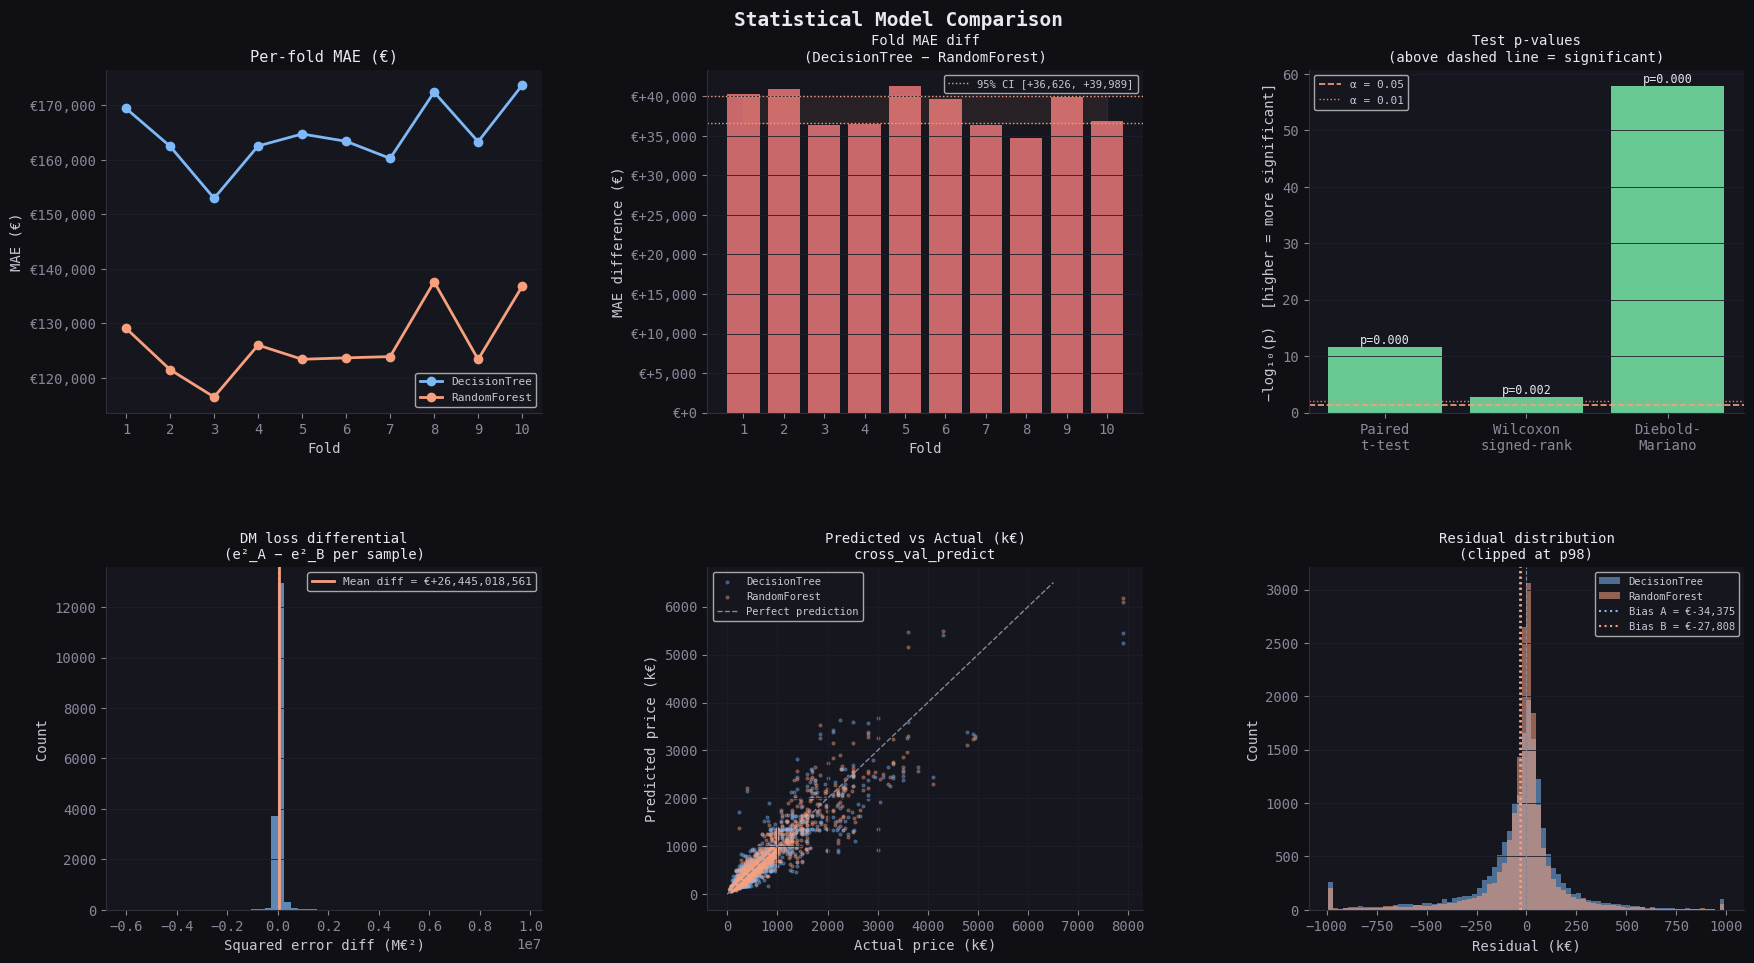

Saved → model_comparison_stats.png


In [ ]:
"""
Statistical Model Comparison
=============================
Tests whether one model is significantly better than another.

Three complementary tests
--------------------------
1. Paired t-test on CV fold errors
   - Simplest. Tests if mean per-fold MAE differs across models.
   - Assumption: fold errors are approximately normal.
   - Fast, interpretable, standard in ML literature.

2. Wilcoxon signed-rank test on CV fold errors
   - Non-parametric alternative to paired t-test.
   - No normality assumption — safer when n_folds is small (10).
   - Preferred when fold score distribution is skewed.

3. Diebold-Mariano test on individual prediction errors
   - Gold standard for comparing forecasting/regression models.
   - Works on per-sample squared errors, not per-fold aggregates.
   - Accounts for autocorrelation in the error series.
   - Used in academic papers and production model selection.

Which to trust
--------------
All three agreeing → strong evidence.
t-test says significant, Wilcoxon does not → check normality of fold scores.
DM says significant, fold tests do not → difference exists at sample level
  but may not be stable across data splits (possible overfit to test set).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn import model_selection
from sklearn.tree     import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import make_scorer, mean_absolute_error

# ── Reuse euro-scale scorer from overfit_check.py ────────────────────────────
def _mae_euros(y_true, y_pred):
    return mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

scorer_mae = make_scorer(_mae_euros, greater_is_better=False)

MODELS = {
    "DecisionTree": DecisionTreeRegressor(
        max_depth=8, min_samples_leaf=20, min_samples_split=40),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=10, random_state=42, n_jobs=-1),
}
CV10 = model_selection.KFold(n_splits=10, shuffle=True, random_state=42)


# ════════════════════════════════════════════════════════════════════════════
# 1. Collect per-fold MAE in euros for each model
# ════════════════════════════════════════════════════════════════════════════
print("Running 10-fold CV for both models …")
fold_errors = {}   # {model_name: array of shape (10,) in €}

for name, model in MODELS.items():
    cv = model_selection.cross_validate(
        model, X_train, y_train,
        scoring={"mae": scorer_mae},
        cv=CV10, return_train_score=False, n_jobs=-1,
    )
    fold_errors[name] = cv["test_mae"] * -1   # positive €

names   = list(fold_errors.keys())
errors_a = fold_errors[names[0]]   # DecisionTree fold MAEs
errors_b = fold_errors[names[1]]   # RandomForest fold MAEs
diff     = errors_a - errors_b     # positive = A worse than B


# ════════════════════════════════════════════════════════════════════════════
# 2. Paired t-test
# ════════════════════════════════════════════════════════════════════════════
# H0: mean(MAE_A - MAE_B) = 0  (no difference)
# H1: mean(MAE_A - MAE_B) ≠ 0  (one is better)
t_stat, p_ttest = stats.ttest_rel(errors_a, errors_b)
ci_low, ci_high = stats.t.interval(
    0.95, df=len(diff)-1,
    loc=diff.mean(),
    scale=stats.sem(diff)
)


# ════════════════════════════════════════════════════════════════════════════
# 3. Wilcoxon signed-rank test
# ════════════════════════════════════════════════════════════════════════════
# Non-parametric — no normality assumption.
# H0: median(MAE_A - MAE_B) = 0
w_stat, p_wilcoxon = stats.wilcoxon(errors_a, errors_b)


# ════════════════════════════════════════════════════════════════════════════
# 4. Diebold-Mariano test on per-sample squared errors
# ════════════════════════════════════════════════════════════════════════════
# Uses the held-out predictions from cross_val_predict — one prediction
# per sample using the fold it was held out from.
print("Computing cross_val_predict for DM test …")

pred_a_log = model_selection.cross_val_predict(
    MODELS[names[0]], X_train, y_train, cv=CV10, n_jobs=-1)
pred_b_log = model_selection.cross_val_predict(
    MODELS[names[1]], X_train, y_train, cv=CV10, n_jobs=-1)

y_euros     = np.expm1(y_train)
pred_a_eur  = np.expm1(pred_a_log)
pred_b_eur  = np.expm1(pred_b_log)

e_a = (y_euros - pred_a_eur) ** 2   # squared errors model A
e_b = (y_euros - pred_b_eur) ** 2   # squared errors model B
d   = e_a - e_b                     # loss differential per sample

# DM statistic: d-bar / sqrt(variance of d)
# Harvey, Leybourne & Newbold (1997) small-sample correction applied
n       = len(d)
d_bar   = d.mean()
d_var   = d.var(ddof=1)
dm_stat = d_bar / np.sqrt(d_var / n)

# Small-sample correction (HLN)
hln_correction = np.sqrt((n + 1 - 2 + 1/n) / n)
dm_stat_hln    = dm_stat * hln_correction
p_dm           = 2 * stats.t.sf(abs(dm_stat_hln), df=n - 1)


# ════════════════════════════════════════════════════════════════════════════
# 5. Print results table
# ════════════════════════════════════════════════════════════════════════════
alpha = 0.05

def _verdict(p):
    if p < 0.001: return "★★★ p<0.001  highly significant"
    if p < 0.01:  return "★★  p<0.01   significant"
    if p < 0.05:  return "★   p<0.05   significant"
    if p < 0.10:  return "~   p<0.10   marginal"
    return              "✗   p≥0.10   not significant"

better = names[0] if diff.mean() > 0 else names[1]
margin = abs(diff.mean())

print(f"\n{'═'*65}")
print(f"  Model A : {names[0]:<20}  mean fold MAE = €{errors_a.mean():>9,.0f}")
print(f"  Model B : {names[1]:<20}  mean fold MAE = €{errors_b.mean():>9,.0f}")
print(f"  Better  : {better}  (by €{margin:,.0f} mean fold MAE)")
print(f"{'─'*65}")
print(f"  {'Test':<28} {'Statistic':>10} {'p-value':>10}  Verdict")
print(f"{'─'*65}")
print(f"  {'Paired t-test':<28} {t_stat:>10.3f} {p_ttest:>10.4f}  {_verdict(p_ttest)}")
print(f"  {'Wilcoxon signed-rank':<28} {w_stat:>10.3f} {p_wilcoxon:>10.4f}  {_verdict(p_wilcoxon)}")
print(f"  {'Diebold-Mariano (HLN)':<28} {dm_stat_hln:>10.3f} {p_dm:>10.4f}  {_verdict(p_dm)}")
print(f"{'─'*65}")
print(f"  95% CI on fold MAE diff : [€{ci_low:,.0f}, €{ci_high:,.0f}]")
print(f"  (positive = {names[0]} has higher MAE)")
print(f"{'═'*65}\n")


# ════════════════════════════════════════════════════════════════════════════
# 6. Visual
# ════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "figure.facecolor": "#0f0f14", "axes.facecolor":  "#16161e",
    "axes.edgecolor":   "#2e2e3a", "axes.labelcolor": "#c8c8d4",
    "axes.titlecolor":  "#e8e8f0", "xtick.color":     "#888899",
    "ytick.color":      "#888899", "text.color":      "#c8c8d4",
    "grid.color":       "#1e1e2a", "font.family":     "monospace",
    "axes.spines.top":  False,     "axes.spines.right": False,
})

fig = plt.figure(figsize=(18, 10), facecolor="#0f0f14")
fig.suptitle("Statistical Model Comparison",
             fontsize=14, fontweight="bold", color="#e8e8f0")

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.38,
                       left=0.06, right=0.97, top=0.92, bottom=0.08)

COLORS = {"DecisionTree": "#7eb8f7", "RandomForest": "#f7a07e"}
folds  = np.arange(1, 11)

# ── Panel A: per-fold MAE in euros ───────────────────────────────────────────
axA = fig.add_subplot(gs[0, 0])
axA.plot(folds, errors_a, "o-", color=COLORS[names[0]], lw=2,
         label=names[0], ms=6)
axA.plot(folds, errors_b, "o-", color=COLORS[names[1]], lw=2,
         label=names[1], ms=6)
axA.set_title("Per-fold MAE (€)", fontsize=11)
axA.set_xlabel("Fold"); axA.set_ylabel("MAE (€)")
axA.set_xticks(folds)
axA.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
axA.legend(fontsize=8); axA.grid(True, axis="y")

# ── Panel B: per-fold MAE difference with CI ─────────────────────────────────
axB = fig.add_subplot(gs[0, 1])
bar_colors = ["#f77e7e" if d > 0 else "#7ef7b0" for d in diff]
axB.bar(folds, diff, color=bar_colors, alpha=0.8, edgecolor="none")
axB.axhline(0,          color="#888899", lw=0.8, ls="--")
axB.axhline(ci_high,    color="#f7a07e", lw=1,   ls=":",
            label=f"95% CI [{ci_low:+,.0f}, {ci_high:+,.0f}]")
axB.axhline(ci_low,     color="#f7a07e", lw=1,   ls=":")
axB.fill_between(folds, ci_low, ci_high, alpha=0.08, color="#f7a07e")
axB.set_title(f"Fold MAE diff\n({names[0]} − {names[1]})", fontsize=10)
axB.set_xlabel("Fold"); axB.set_ylabel("MAE difference (€)")
axB.set_xticks(folds)
axB.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:+,.0f}"))
axB.legend(fontsize=7.5); axB.grid(True, axis="y")

# ── Panel C: p-value summary bar chart ───────────────────────────────────────
axC = fig.add_subplot(gs[0, 2])
test_names = ["Paired\nt-test", "Wilcoxon\nsigned-rank", "Diebold-\nMariano"]
p_values   = [p_ttest, p_wilcoxon, p_dm]
p_colors   = ["#7ef7b0" if p < alpha else "#f77e7e" for p in p_values]

bars = axC.bar(test_names, [-np.log10(p) for p in p_values],
               color=p_colors, alpha=0.8, edgecolor="none")
axC.axhline(-np.log10(0.05),  color="#f7a07e", ls="--", lw=1.2,
            label="α = 0.05")
axC.axhline(-np.log10(0.01),  color="#f77e7e", ls=":",  lw=1,
            label="α = 0.01")

for bar, p in zip(bars, p_values):
    axC.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"p={p:.3f}", ha="center", va="bottom", fontsize=8.5,
             color="#e8e8f0")

axC.set_ylabel("−log₁₀(p)  [higher = more significant]")
axC.set_title("Test p-values\n(above dashed line = significant)", fontsize=10)
axC.legend(fontsize=8); axC.grid(True, axis="y")

# ── Panel D: DM loss differential distribution ───────────────────────────────
axD = fig.add_subplot(gs[1, 0])
axD.hist(d / 1e6, bins=60, color="#7eb8f7", alpha=0.7, edgecolor="none")
axD.axvline(0,       color="#888899", lw=0.8, ls="--")
axD.axvline(d.mean() / 1e6, color="#f7a07e", lw=2,
            label=f"Mean diff = €{d.mean():+,.0f}")
axD.set_title("DM loss differential\n(e²_A − e²_B per sample)", fontsize=10)
axD.set_xlabel("Squared error diff (M€²)")
axD.set_ylabel("Count")
axD.legend(fontsize=8); axD.grid(True, axis="y")

# ── Panel E: predicted vs actual scatter (both models) ───────────────────────
axE = fig.add_subplot(gs[1, 1])
sample = np.random.default_rng(0).choice(len(y_euros),
                                          size=min(1500, len(y_euros)),
                                          replace=False)
axE.scatter(y_euros.iloc[sample] / 1e3, pred_a_eur[sample] / 1e3,
            s=4, alpha=0.35, color=COLORS[names[0]], label=names[0],
            rasterized=True)
axE.scatter(y_euros.iloc[sample] / 1e3, pred_b_eur[sample] / 1e3,
            s=4, alpha=0.35, color=COLORS[names[1]], label=names[1],
            rasterized=True)
lim = max(y_euros.quantile(0.99), pred_b_eur.max()) / 1e3
axE.plot([0, lim], [0, lim], color="#888899", lw=1, ls="--",
         label="Perfect prediction")
axE.set_title("Predicted vs Actual (k€)\ncross_val_predict", fontsize=10)
axE.set_xlabel("Actual price (k€)")
axE.set_ylabel("Predicted price (k€)")
axE.legend(fontsize=7.5); axE.grid(True)

# ── Panel F: residual distribution comparison ────────────────────────────────
axF = fig.add_subplot(gs[1, 2])
res_a = (pred_a_eur - y_euros) / 1e3
res_b = (pred_b_eur - y_euros) / 1e3
clip  = np.percentile(np.abs(res_a), 98)

axF.hist(np.clip(res_a, -clip, clip), bins=80, alpha=0.55,
         color=COLORS[names[0]], edgecolor="none", label=names[0])
axF.hist(np.clip(res_b, -clip, clip), bins=80, alpha=0.55,
         color=COLORS[names[1]], edgecolor="none", label=names[1])
axF.axvline(0, color="#888899", lw=0.8, ls="--")
axF.axvline(res_a.mean(), color=COLORS[names[0]], lw=1.5,
            ls=":", label=f"Bias A = €{res_a.mean()*1e3:+,.0f}")
axF.axvline(res_b.mean(), color=COLORS[names[1]], lw=1.5,
            ls=":", label=f"Bias B = €{res_b.mean()*1e3:+,.0f}")
axF.set_title("Residual distribution\n(clipped at p98)", fontsize=10)
axF.set_xlabel("Residual (k€)")
axF.set_ylabel("Count")
axF.legend(fontsize=7.5); axF.grid(True, axis="y")

fig.savefig("model_comparison_stats.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → model_comparison_stats.png")

Device: cpu
Parameters: 608,641

───────────────────────────────────────────────────────
 Epoch   Train Loss     Val Loss           LR
───────────────────────────────────────────────────────
     1      1.26286      0.47195     9.94e-04
    10      0.03926      0.03319     5.01e-04
    20      0.02327      0.02375     1.00e-03
    30      0.03676      0.02999     8.54e-04
    40      0.03678      0.03499     5.01e-04

Early stop at epoch 43 (best val loss: 0.02322)
───────────────────────────────────────────────────────

────────────────────────────────────────
  MAE   : €     121,275   ← primary
  MedAE : €      44,415   ← robust
  RMSE  : €     271,730
  MAPE  :        16.87%
────────────────────────────────────────


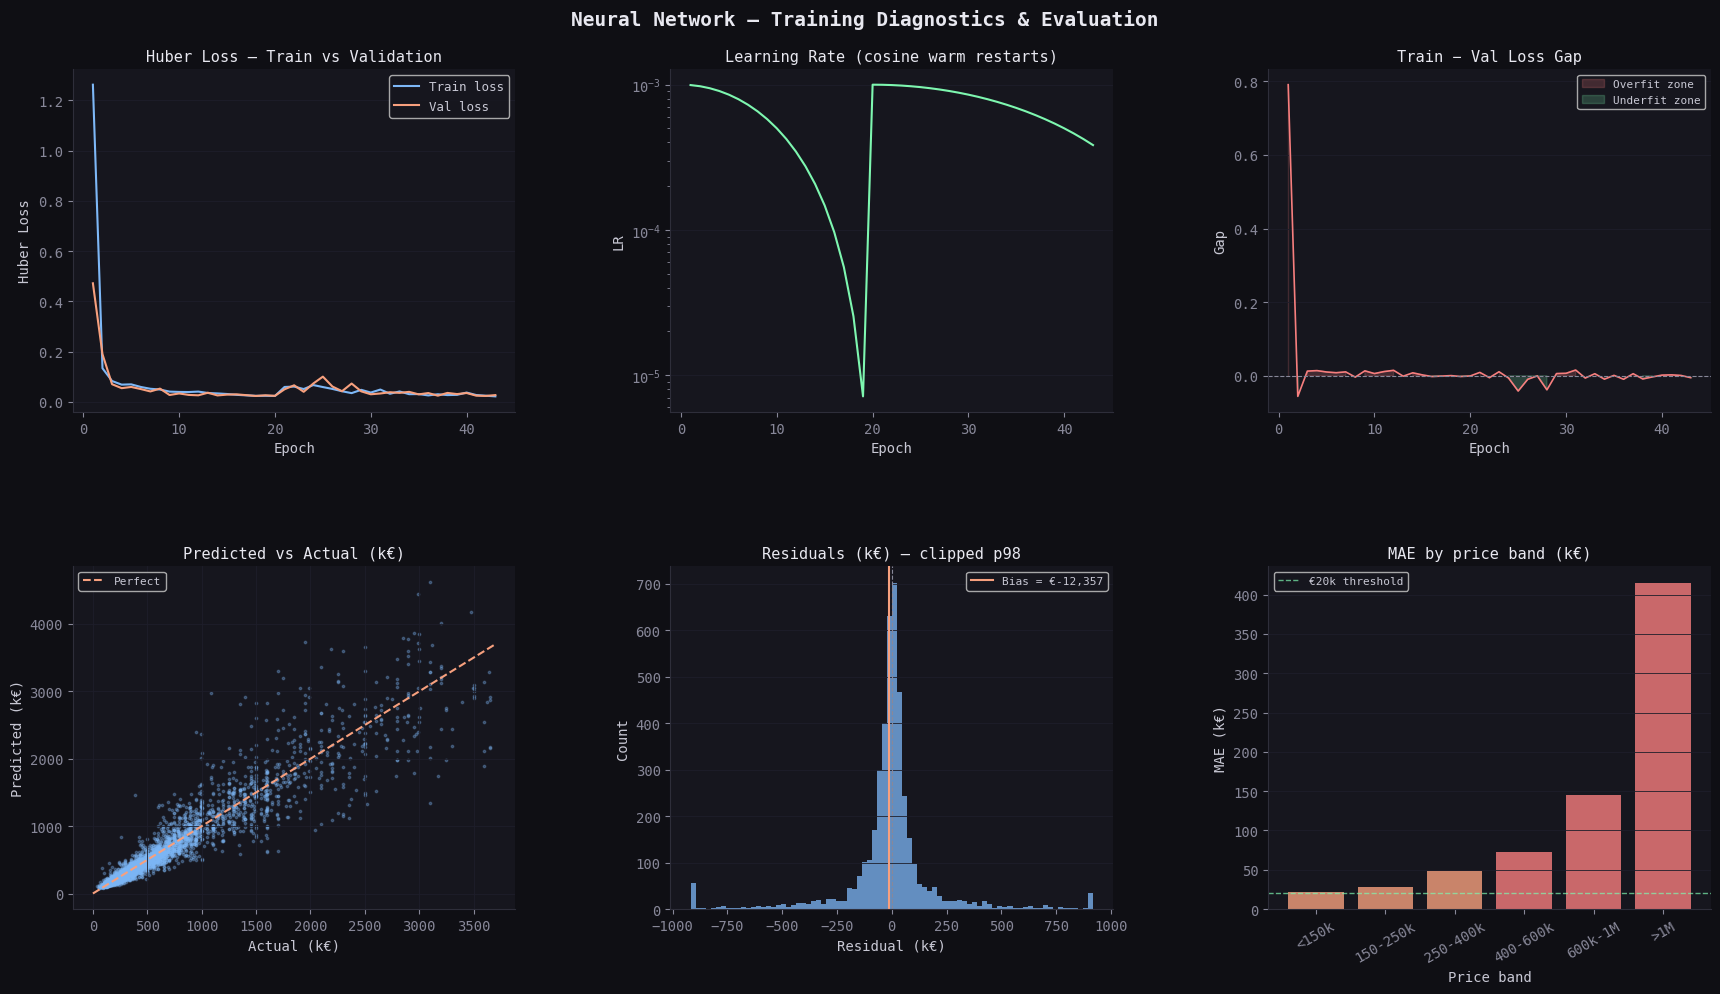

Saved → nn_diagnostics.png


In [ ]:
"""
Neural Network Regression — Madrid Real Estate (240 features)
==============================================================
Architecture designed for tabular data with mixed feature types:
  - continuous numeric (sq_mt_built, n_rooms, …)
  - ordinal (neighborhood_rank, addr_number_bucket, …)
  - binary dummies (has_lift, house_type_id_*, district_*, …)

Key design decisions explained inline.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import RobustScaler
from sklearn.metrics         import mean_absolute_error, median_absolute_error


# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


# ════════════════════════════════════════════════════════════════════════════
# 1. Data preparation
# ════════════════════════════════════════════════════════════════════════════

# Split off a validation set in addition to test
# (test set never touched during training or architecture decisions)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

# Scale X — NNs are sensitive to input scale unlike trees.
# RobustScaler applied to ALL 240 columns including binaries.
# Binary columns scaled to roughly [-0.5, 0.5] — acceptable for NNs,
# and avoids maintaining two separate scaling pipelines.
scaler   = RobustScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_te_s   = scaler.transform(X_test)

def to_tensors(*arrays):
    return [torch.tensor(a, dtype=torch.float32) for a in arrays]

Xtr_t, ytr_t   = to_tensors(X_tr_s,  y_tr.values.reshape(-1, 1))
Xval_t, yval_t = to_tensors(X_val_s, y_val.values.reshape(-1, 1))
Xte_t,  yte_t  = to_tensors(X_te_s,  y_test.values.reshape(-1, 1))

train_loader = DataLoader(
    TensorDataset(Xtr_t, ytr_t),
    batch_size=256, shuffle=True, drop_last=True
)


# ════════════════════════════════════════════════════════════════════════════
# 2. Architecture — MLP with residual connections
# ════════════════════════════════════════════════════════════════════════════

class ResidualBlock(nn.Module):
    """
    One residual block: Linear → BN → GELU → Dropout → Linear → BN
    then adds the input (skip connection).

    Why residual connections for tabular data?
    ------------------------------------------
    With 240 features and a 4-layer deep network, gradients can vanish
    through the depth. The skip connection gives gradients a direct path
    back to earlier layers — same reason ResNets work for images, but here
    the motivation is gradient flow, not spatial hierarchy.
    The block preserves dimensionality so the skip add is always valid.
    """
    def __init__(self, dim: int, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),                  # smoother than ReLU, works well on tabular
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))   # skip connection


class TabularMLP(nn.Module):
    """
    Input projection → stack of residual blocks → output head.

    Architecture choices for 240 mixed features
    --------------------------------------------
    Input dim  : 240 (all features after feature_pipeline)
    Hidden dim : 256 — wider than input to let the network expand the
                 representation before compressing. 512 is also common
                 but slower; 128 is too narrow for 240 features.
    Depth      : 4 residual blocks ≈ 8 effective linear layers.
                 Deeper than 6 blocks rarely helps on tabular data
                 (Gorishniy et al. 2021 — "Revisiting Deep Learning
                 Models for Tabular Data").
    Dropout    : 0.3 — standard for tabular. Higher (0.5) risks
                 underfitting on small datasets; lower (0.1) risks overfit.
    BatchNorm  : inside each block on the hidden representations,
                 NOT on the input (RobustScaler already handled that).
    Output     : single neuron, no activation — predicting log1p(price),
                 which is unbounded and approximately normal.
    """
    def __init__(self,
                 input_dim:  int   = 240,
                 hidden_dim: int   = 256,
                 n_blocks:   int   = 4,
                 dropout:    float = 0.3):
        super().__init__()

        # Input projection — maps 240 → hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)]
        )

        # Output head — compress to 1
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        return self.head(x)


# ════════════════════════════════════════════════════════════════════════════
# 3. Training setup
# ════════════════════════════════════════════════════════════════════════════

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

input_dim = X_tr_s.shape[1]
model_nn  = TabularMLP(input_dim=input_dim).to(device)
print(f"Parameters: {sum(p.numel() for p in model_nn.parameters()):,}")

# Loss: Huber (smooth L1) instead of MSE.
# Why Huber for real estate?
# MSE squares large errors → luxury outliers dominate the gradient.
# Huber behaves like MSE for small errors but like MAE for large ones.
# delta=0.5 on log scale corresponds to ~€65k error before switching
# to linear loss — tuned to Madrid's price distribution.
criterion = nn.HuberLoss(delta=0.5)

# AdamW — Adam with decoupled weight decay.
# Weight decay = L2 regularisation on the 240-feature input layer
# prevents individual features from dominating the network.
optimizer = torch.optim.AdamW(
    model_nn.parameters(), lr=1e-3, weight_decay=1e-4
)

# Cosine annealing with warm restarts.
# Learning rate oscillates: high → low → reset.
# Allows the model to escape local minima between restarts.
# T_0=20: first cycle is 20 epochs; T_mult=2: each cycle doubles.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6
)


# ════════════════════════════════════════════════════════════════════════════
# 4. Training loop with early stopping
# ════════════════════════════════════════════════════════════════════════════

N_EPOCHS    = 200
PATIENCE    = 25      # stop if val loss doesn't improve for 25 epochs

best_val_loss = np.inf
patience_cnt  = 0
best_state    = None

history = {"train": [], "val": [], "lr": []}

print(f"\n{'─'*55}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>12}")
print(f"{'─'*55}")

for epoch in range(1, N_EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────────
    model_nn.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_nn(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        # Gradient clipping — prevents exploding gradients on outlier batches
        nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(Xb)

    train_loss /= len(Xtr_t)
    scheduler.step()

    # ── Validate ─────────────────────────────────────────────────────────
    model_nn.eval()
    with torch.no_grad():
        val_pred = model_nn(Xval_t.to(device)).cpu()
        val_loss = criterion(val_pred, yval_t).item()

    history["train"].append(train_loss)
    history["val"].append(val_loss)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} {train_loss:>12.5f} {val_loss:>12.5f} "
              f"{optimizer.param_groups[0]['lr']:>12.2e}")

    # ── Early stopping ───────────────────────────────────────────────────
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model_nn.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch} "
                  f"(best val loss: {best_val_loss:.5f})")
            break

# Restore best weights
model_nn.load_state_dict(best_state)
print(f"{'─'*55}")


# ════════════════════════════════════════════════════════════════════════════
# 5. Evaluation — euros
# ════════════════════════════════════════════════════════════════════════════

model_nn.eval()
with torch.no_grad():
    pred_log = model_nn(Xte_t.to(device)).cpu().numpy().flatten()

pred_euros = np.expm1(np.clip(pred_log, 0, 30))
true_euros = np.expm1(y_test.values)

mae   = mean_absolute_error(true_euros, pred_euros)
medae = median_absolute_error(true_euros, pred_euros)
mape  = np.mean(np.abs((true_euros - pred_euros) / true_euros)) * 100
rmse  = np.sqrt(np.mean((true_euros - pred_euros) ** 2))

print(f"\n{'─'*40}")
print(f"  MAE   : €{mae:>12,.0f}   ← primary")
print(f"  MedAE : €{medae:>12,.0f}   ← robust")
print(f"  RMSE  : €{rmse:>12,.0f}")
print(f"  MAPE  :  {mape:>11.2f}%")
print(f"{'─'*40}")


# ════════════════════════════════════════════════════════════════════════════
# 6. Diagnostic plots
# ════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "figure.facecolor": "#0f0f14", "axes.facecolor":  "#16161e",
    "axes.edgecolor":   "#2e2e3a", "axes.labelcolor": "#c8c8d4",
    "axes.titlecolor":  "#e8e8f0", "xtick.color":     "#888899",
    "ytick.color":      "#888899", "text.color":      "#c8c8d4",
    "grid.color":       "#1e1e2a", "font.family":     "monospace",
    "axes.spines.top":  False,     "axes.spines.right": False,
})

fig = plt.figure(figsize=(18, 10), facecolor="#0f0f14")
fig.suptitle("Neural Network — Training Diagnostics & Evaluation",
             fontsize=14, fontweight="bold", color="#e8e8f0")
gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       left=0.06, right=0.97, top=0.92, bottom=0.08)

epochs = np.arange(1, len(history["train"]) + 1)

# ── A: Loss curves ────────────────────────────────────────────────────────
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs, history["train"], color="#7eb8f7", lw=1.5, label="Train loss")
axA.plot(epochs, history["val"],   color="#f7a07e", lw=1.5, label="Val loss")
axA.set_title("Huber Loss — Train vs Validation", fontsize=11)
axA.set_xlabel("Epoch"); axA.set_ylabel("Huber Loss")
axA.legend(fontsize=9); axA.grid(True, axis="y")

# ── B: Learning rate schedule ────────────────────────────────────────────
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs, history["lr"], color="#7ef7b0", lw=1.5)
axB.set_title("Learning Rate (cosine warm restarts)", fontsize=11)
axB.set_xlabel("Epoch"); axB.set_ylabel("LR")
axB.set_yscale("log"); axB.grid(True, axis="y")

# ── C: Train−Val gap curve ────────────────────────────────────────────────
axC = fig.add_subplot(gs[0, 2])
gap = np.array(history["train"]) - np.array(history["val"])
axC.plot(epochs, gap, color="#f77e7e", lw=1.2)
axC.axhline(0, color="#888899", lw=0.8, ls="--")
axC.fill_between(epochs, 0, gap,
                 where=(gap > 0), alpha=0.2, color="#f77e7e",
                 label="Overfit zone")
axC.fill_between(epochs, 0, gap,
                 where=(gap < 0), alpha=0.2, color="#7ef7b0",
                 label="Underfit zone")
axC.set_title("Train − Val Loss Gap", fontsize=11)
axC.set_xlabel("Epoch"); axC.set_ylabel("Gap")
axC.legend(fontsize=8); axC.grid(True, axis="y")

# ── D: Predicted vs Actual ────────────────────────────────────────────────
axD = fig.add_subplot(gs[1, 0])
clip99 = np.percentile(true_euros, 99)
mask   = true_euros < clip99
axD.scatter(true_euros[mask] / 1e3, pred_euros[mask] / 1e3,
            s=3, alpha=0.3, color="#7eb8f7", rasterized=True)
lim = clip99 / 1e3
axD.plot([0, lim], [0, lim], color="#f7a07e", lw=1.5, ls="--",
         label="Perfect")
axD.set_title("Predicted vs Actual (k€)", fontsize=11)
axD.set_xlabel("Actual (k€)"); axD.set_ylabel("Predicted (k€)")
axD.legend(fontsize=8); axD.grid(True)

# ── E: Residual distribution ──────────────────────────────────────────────
axE = fig.add_subplot(gs[1, 1])
residuals = (pred_euros - true_euros) / 1e3
clip_r    = np.percentile(np.abs(residuals), 98)
axE.hist(np.clip(residuals, -clip_r, clip_r),
         bins=80, color="#7eb8f7", alpha=0.75, edgecolor="none")
axE.axvline(0,               color="#888899", lw=0.8, ls="--")
axE.axvline(residuals.mean(), color="#f7a07e", lw=1.5,
            label=f"Bias = €{residuals.mean()*1e3:+,.0f}")
axE.set_title("Residuals (k€) — clipped p98", fontsize=11)
axE.set_xlabel("Residual (k€)"); axE.set_ylabel("Count")
axE.legend(fontsize=8); axE.grid(True, axis="y")

# ── F: Error by price band ────────────────────────────────────────────────
axF = fig.add_subplot(gs[1, 2])
bands      = [0, 150, 250, 400, 600, 1000, np.inf]
band_labels= ["<150k", "150-250k", "250-400k",
              "400-600k", "600k-1M", ">1M"]
abs_errors = np.abs(pred_euros - true_euros)
band_mae   = []
for lo, hi in zip(bands[:-1], bands[1:]):
    mask = (true_euros >= lo * 1e3) & (true_euros < hi * 1e3)
    band_mae.append(abs_errors[mask].mean() if mask.sum() > 0 else 0)

bar_colors = ["#7ef7b0" if m < 20000 else
              "#f7a07e" if m < 50000 else "#f77e7e" for m in band_mae]
axF.bar(band_labels, [m / 1e3 for m in band_mae],
        color=bar_colors, alpha=0.8, edgecolor="none")
axF.axhline(20, color="#7ef7b0", ls="--", lw=1, alpha=0.7,
            label="€20k threshold")
axF.set_title("MAE by price band (k€)", fontsize=11)
axF.set_xlabel("Price band"); axF.set_ylabel("MAE (k€)")
axF.tick_params(axis="x", rotation=30)
axF.legend(fontsize=8); axF.grid(True, axis="y")

fig.savefig("nn_diagnostics.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → nn_diagnostics.png")

In [ ]:
X_train.head()

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_rent_price_known,is_renewal_needed,has_lift,is_exterior,has_parking,addr_has_number,...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
17739,127.0,4,2.0,True,False,False,True,True,True,0,...,True,False,False,False,False,False,False,False,False,False
17096,80.0,3,1.0,True,False,False,True,True,True,0,...,True,False,False,False,False,False,False,False,False,False
17360,160.0,3,2.0,True,False,False,True,True,False,0,...,False,False,False,False,False,True,False,False,False,False
18013,162.0,5,2.0,True,False,False,True,True,False,0,...,False,False,False,False,False,True,False,False,False,False
7274,508.0,6,5.0,True,False,False,True,True,True,0,...,False,False,False,False,False,True,False,False,False,False


In [296]:
import re

def clean_feature_names(X: pd.DataFrame) -> pd.DataFrame:
    """
    Sanitise column names for LightGBM compatibility.
    Replaces any character that is not alphanumeric or underscore with '_',
    then collapses consecutive underscores.
    """
    X = X.copy()
    X.columns = [
        re.sub(r"_+", "_",              # collapse consecutive underscores
        re.sub(r"[^A-Za-z0-9_]", "_",  # replace illegal chars with _
        col)).strip("_")
        for col in X.columns
    ]
    return X

X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

In [ ]:
X_train

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_rent_price_known,is_renewal_needed,has_lift,is_exterior,has_parking,addr_has_number,...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
17739,127.0,4,2.0,True,False,False,True,True,True,0,...,True,False,False,False,False,False,False,False,False,False
17096,80.0,3,1.0,True,False,False,False,True,True,0,...,True,False,False,False,False,False,False,False,False,False
17360,160.0,3,2.0,True,False,False,True,True,False,0,...,False,False,False,False,False,True,False,False,False,False
18013,162.0,5,2.0,True,False,False,False,True,False,0,...,False,False,False,False,False,True,False,False,False,False
7274,508.0,6,5.0,True,False,False,True,True,True,0,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
"""
Model Selection — Nested Cross-Validation
==========================================
5 model types compared on Madrid real estate buy_price prediction.

Nested CV structure
-------------------
Outer loop (5 folds)  — unbiased generalisation estimate
  Inner loop (3 folds) — hyperparameter search via RandomizedSearchCV

FAST MODE  (FAST = True)
------------------------
Cuts runtime from ~30 min to ~2-3 min:
  • Subsamples X_train to FAST_SAMPLE_SIZE rows (stratified by price quantile)
  • Reduces outer CV to 3 folds instead of 5
  • Reduces inner CV to 2 folds instead of 3
  • Cuts n_iter in half for all models
  • Narrows param grids to the 2 most impactful params per model
Purpose: rapid architecture validation, not final model selection.
Set FAST = False for the final production run.
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import (KFold, RandomizedSearchCV,
                                      cross_val_score)
from sklearn.linear_model     import Ridge, ElasticNet
from sklearn.ensemble         import GradientBoostingRegressor
from sklearn.metrics          import make_scorer, mean_absolute_error
from sklearn.preprocessing    import RobustScaler
from sklearn.pipeline         import Pipeline
from sklearn.base import clone
import xgboost  as xgb
import lightgbm as lgb

# ══════════════════════════════════════════════════════════════════════════════
# MODE SWITCH — flip this flag to trade speed for rigour
# ══════════════════════════════════════════════════════════════════════════════
FAST = False          # True  → ~2-3 min,  for exploration
                      # False → ~30 min,   for final model selection

FAST_SAMPLE_SIZE = 3_000   # rows used in fast mode (from full X_train)

# ── Euro-scale MAE scorer (back-transform from log) ──────────────────────────
def mae_euros(y_true, y_pred):
    return mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

scorer = make_scorer(mae_euros, greater_is_better=False)

# ── CV folds — narrowed in fast mode ─────────────────────────────────────────
outer_cv = KFold(n_splits=3 if FAST else 5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=2 if FAST else 3, shuffle=True, random_state=42)

# ── Data — subsample in fast mode ────────────────────────────────────────────
if FAST:
    _idx = (
        pd.qcut(y_train, q=10, labels=False, duplicates="drop")  # price quantile
          .groupby(pd.qcut(y_train, q=10, labels=False, duplicates="drop"))
          .apply(lambda g: g.sample(
              min(len(g), FAST_SAMPLE_SIZE // 10), random_state=42))
          .index.get_level_values(1)
    )
    X_run = X_train.loc[_idx].reset_index(drop=True)
    y_run = y_train.loc[_idx].reset_index(drop=True)
    print(f"[FAST MODE] Using {len(X_run):,} / {len(X_train):,} rows  "
          f"({len(X_run)/len(X_train)*100:.0f}%)")
else:
    X_run = X_train
    y_run = y_train
    print("[FULL MODE] Using full training set")

# ── Model + search space definitions ─────────────────────────────────────────
# Each model has two param grids:
#   "params_fast" — 2 most impactful params, few values, fast sweep
#   "params_full" — complete grid for rigorous final selection
# n_iter is also halved in fast mode.

_feature_pipe_template = build_pipeline(X_train)


MODELS = {

    "Ridge": {
        "estimator": Pipeline([
            ("scaler", clone(_feature_pipe_template)),
            ("model",  Ridge()),
        ]),
        "params_full": {
            "model__alpha": np.logspace(-2, 4, 50),
        },
        "params_fast": {
            "model__alpha": np.logspace(-1, 3, 10),   # narrower range, fewer points
        },
        "n_iter": 20,
    },

    "ElasticNet": {
        "estimator": Pipeline([
            ("scaler", clone(_feature_pipe_template)),
            ("model",  ElasticNet(max_iter=5000)),
        ]),
        "params_full": {
            "model__alpha":    np.logspace(-3, 2, 40),
            "model__l1_ratio": np.linspace(0.1, 0.9, 9),
        },
        "params_fast": {
            "model__alpha":    np.logspace(-2, 1, 8),
            "model__l1_ratio": [0.2, 0.5, 0.8],       # sparse vs dense trade-off
        },
        "n_iter": 15,
    },

    "GradientBoosting": {
        "estimator": GradientBoostingRegressor(random_state=42),
        "params_full": {
            "n_estimators":     [200, 400, 600],
            "learning_rate":    [0.01, 0.05, 0.1],
            "max_depth":        [3, 4, 5],
            "subsample":        [0.7, 0.8, 1.0],
            "min_samples_leaf": [10, 20, 30],
        },
        "params_fast": {
            "n_estimators":  [100, 200],               # fewer trees
            "learning_rate": [0.05, 0.1],              # most impactful params
            "max_depth":     [3, 4],
        },
        "n_iter": 12,
    },

    "XGBoost": {
        "estimator": xgb.XGBRegressor(
            tree_method="hist", random_state=42, n_jobs=-1,
            verbosity=0, eval_metric="mae",
        ),
        "params_full": {
            "n_estimators":     [300, 500, 800],
            "learning_rate":    [0.01, 0.05, 0.1],
            "max_depth":        [4, 5, 6, 7],
            "subsample":        [0.7, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "reg_alpha":        [0, 0.1, 0.5, 1.0],
            "reg_lambda":       [0.5, 1.0, 2.0],
            "min_child_weight": [1, 5, 10],
        },
        "params_fast": {
            "n_estimators":  [200, 400],               # most impactful for XGB
            "learning_rate": [0.05, 0.1],
            "max_depth":     [4, 6],
            "reg_alpha":     [0, 0.1],
        },
        "n_iter": 20,
    },

    "LightGBM": {
        "estimator": lgb.LGBMRegressor(
            random_state=42, n_jobs=-1, verbose=-1,
        ),
        "params_full": {
            "n_estimators":      [300, 500, 800],
            "learning_rate":     [0.01, 0.05, 0.1],
            "max_depth":         [-1, 5, 7, 10],
            "num_leaves":        [31, 63, 127],
            "subsample":         [0.7, 0.8, 1.0],
            "colsample_bytree":  [0.6, 0.8, 1.0],
            "reg_alpha":         [0, 0.1, 0.5],
            "reg_lambda":        [0, 0.1, 1.0],
            "min_child_samples": [10, 20, 30],
        },
        "params_fast": {
            "n_estimators":  [200, 400],               # most impactful for LGB
            "learning_rate": [0.05, 0.1],
            "num_leaves":    [31, 63],                 # LGB's primary complexity knob
            "reg_lambda":    [0, 0.1],
        },
        "n_iter": 20,
    },
}


# ════════════════════════════════════════════════════════════════════════════
# Nested CV loop
# ════════════════════════════════════════════════════════════════════════════
mode_label = "FAST" if FAST else "FULL"
outer_n    = 3 if FAST else 5
inner_n    = 2 if FAST else 3

print(f"\n{'═'*70}")
print(f"  Nested CV — Model Selection  [{mode_label} MODE]")
print(f"  Outer: {outer_n}-fold  |  Inner: {inner_n}-fold RandomizedSearch")
if FAST:
    print(f"  Data : {len(X_run):,} rows  |  Narrow param grids  |  Halved n_iter")
    print(f"  ⚠  Fast mode scores are indicative — run FAST=False for final selection")
print(f"{'═'*70}\n")

summary = []

for name, cfg in MODELS.items():
    params  = cfg["params_fast"] if FAST else cfg["params_full"]
    n_iter  = max(5, cfg["n_iter"] // 2) if FAST else cfg["n_iter"]

    print(f"  ▶ {name:<18} params={len(params)} keys  n_iter={n_iter} … ",
          end="", flush=True)

    search = RandomizedSearchCV(
        estimator           = cfg["estimator"],
        param_distributions = params,
        n_iter              = n_iter,
        cv                  = inner_cv,
        scoring             = scorer,
        refit               = True,
        n_jobs              = -1,
        random_state        = 42,
    )

    # Outer CV — each fold fits a full inner search independently
    outer_scores = cross_val_score(
        search, X_run, y_run,
        cv      = outer_cv,
        scoring = scorer,
        n_jobs  = -1,
    )
    outer_mae = outer_scores * -1   # scorer negates; flip back to positive €

    # Refit on X_run to extract best params for reporting
    search.fit(X_run, y_run)
    best_params = search.best_params_

    summary.append({
        "model":      name,
        "mae_mean":   outer_mae.mean(),
        "mae_std":    outer_mae.std(),
        "mae_folds":  outer_mae,
        "best_params": best_params,
    })

    print(f"MAE €{outer_mae.mean():>8,.0f} ± €{outer_mae.std():>6,.0f}")


# ════════════════════════════════════════════════════════════════════════════
# Results table — sorted by MAE ascending
# ════════════════════════════════════════════════════════════════════════════
summary.sort(key=lambda x: x["mae_mean"])

print(f"\n{'═'*70}")
print(f"  {'Rank':<5} {'Model':<20} {'MAE €':>10} {'± Std':>10}  Best Parameters")
print(f"{'─'*70}")

for rank, row in enumerate(summary, 1):
    # Print only the most impactful params (skip pipeline prefixes)
    params_clean = {
        k.replace("model__", ""): v
        for k, v in row["best_params"].items()
    }
    # Format compactly
    params_str = "  ".join(
        f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
        for k, v in params_clean.items()
    )
    print(f"  {rank:<5} {row['model']:<20} "
          f"€{row['mae_mean']:>9,.0f} ±€{row['mae_std']:>7,.0f}")
    print(f"         └─ {params_str}")
    print()

print(f"{'═'*70}")
winner = summary[0]["model"]
print(f"  Best model: {winner}  "
      f"(€{summary[0]['mae_mean']:,.0f} mean outer-fold MAE)\n")

[FULL MODE] Using full training set
[classify_columns] skewed=4  continuous=0  binary=1

[build_pipeline] Column assignment:
  Skewed continuous (4):    ['sq_mt_built', 'n_rooms', 'n_bathrooms', 'addr_number_bucket']
  Continuous        (0): []
  Binary/dummy      (1):   (first 8) ['addr_has_number']
  PCA disabled (default).  Enable with use_pca=True for linear models.

[build_pipeline] Pipeline assembled with 2 steps.

══════════════════════════════════════════════════════════════════════
  Nested CV — Model Selection  [FULL MODE]
  Outer: 5-fold  |  Inner: 3-fold RandomizedSearch
══════════════════════════════════════════════════════════════════════

  ▶ Ridge              params=1 keys  n_iter=20 … MAE € 211,967 ± € 4,862
  ▶ ElasticNet         params=2 keys  n_iter=15 … MAE € 212,214 ± € 4,885
  ▶ GradientBoosting   params=5 keys  n_iter=12 … MAE € 110,959 ± € 4,729
  ▶ XGBoost            params=8 keys  n_iter=20 … MAE € 108,260 ± € 3,739
  ▶ LightGBM           params=9 keys  n_it

In [ ]:
import sys

sys.exit()

SystemExit: 

In [425]:
# ── Final step ────────────────────────────────────────────────────────────────
best_params = {
    "n_estimators": 800,   "learning_rate": 0.05,
    "max_depth": 5,        "reg_alpha": 0.5,
    "reg_lambda": 2.0,     "min_child_weight": 10,
    "subsample": 0.8,      "colsample_bytree": 0.7,
}

nested_cv_mae = next(
    r["mae_mean"] for r in summary if r["model"] == "XGBoost"
)

best_model = xgb.XGBRegressor(
    tree_method  = "hist",
    random_state = 42,
    n_jobs       = -1,
    verbosity    = 0,
    **best_params,
)

best_model.fit(X_train, y_train)

pred_log   = best_model.predict(X_test)
pred_euros = np.expm1(np.clip(pred_log, 0, 30))
true_euros = np.expm1(y_test)

mae   = mean_absolute_error(true_euros, pred_euros)
medae = median_absolute_error(true_euros, pred_euros)
mape  = np.mean(np.abs((true_euros - pred_euros) / true_euros)) * 100

print(f"Final Test Evaluation — {best_model.__class__.__name__}")
print(f"{'─'*40}")
print(f"  MAE   : €{mae:>10,.0f}   ← report this")
print(f"  MedAE : €{medae:>10,.0f}")
print(f"  MAPE  :  {mape:>9.2f}%")
print(f"{'─'*40}")
print(f"  Nested CV MAE (expected) : €{nested_cv_mae:>8,.0f}")
print(f"  Test MAE                 : €{mae:>8,.0f}")
print(f"  Difference               : €{abs(mae - nested_cv_mae):>8,.0f}")
print(f"  {'✓ consistent' if abs(mae - nested_cv_mae) / nested_cv_mae < 0.05 else '⚠ investigate gap'}")

Final Test Evaluation — XGBRegressor
────────────────────────────────────────
  MAE   : €   115,860   ← report this
  MedAE : €    42,253
  MAPE  :      16.09%
────────────────────────────────────────
  Nested CV MAE (expected) : € 108,260
  Test MAE                 : € 115,860
  Difference               : €   7,600
  ⚠ investigate gap


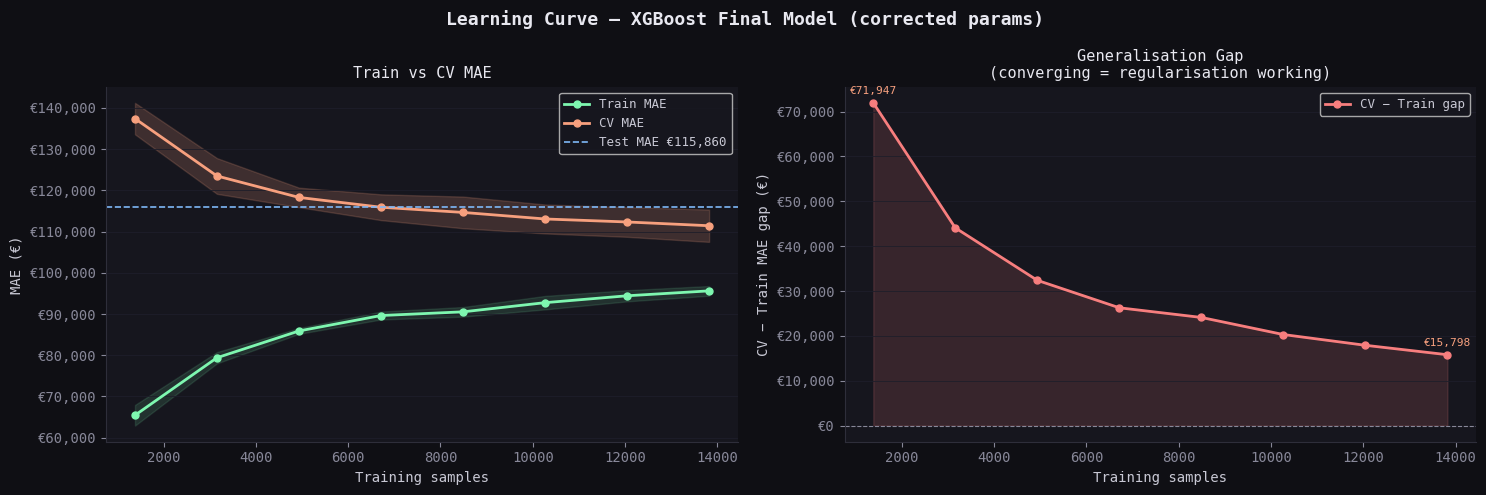

In [426]:
# ── Learning curve ────────────────────────────────────────────────────────────
sizes, tr_scores, te_scores = learning_curve(
    xgb.XGBRegressor(tree_method="hist", random_state=42,
                     n_jobs=-1, verbosity=0, **best_params),
    X_train, y_train,
    train_sizes = np.linspace(0.1, 1.0, 8),
    cv          = KFold(n_splits=5, shuffle=True, random_state=42),
    scoring     = scorer,
    n_jobs      = -1,
)

tr     = tr_scores.mean(axis=1) * -1;  tr_std = tr_scores.std(axis=1)
te     = te_scores.mean(axis=1) * -1;  te_std = te_scores.std(axis=1)
gap    = te - tr

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor="#0f0f14")
fig.suptitle("Learning Curve — XGBoost Final Model (corrected params)",
             color="#e8e8f0", fontsize=13, fontweight="bold")

# ── Left: MAE curves ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#16161e")
ax.plot(sizes, tr, "o-", color="#7ef7b0", lw=2, label="Train MAE", ms=5)
ax.plot(sizes, te, "o-", color="#f7a07e", lw=2, label="CV MAE",    ms=5)
ax.fill_between(sizes, tr - tr_std, tr + tr_std, alpha=0.12, color="#7ef7b0")
ax.fill_between(sizes, te - te_std, te + te_std, alpha=0.18, color="#f7a07e")
ax.axhline(mae, color="#7eb8f7", ls="--", lw=1.2,
           label=f"Test MAE €{mae:,.0f}")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_xlabel("Training samples"); ax.set_ylabel("MAE (€)")
ax.set_title("Train vs CV MAE", color="#e8e8f0", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis="y", color="#1e1e2a")
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

# ── Right: Gap curve — the convergence signal ─────────────────────────────────
# Gap closing toward zero = regularisation working
# Gap flat or wide        = still overfitting
ax2 = axes[1]
ax2.set_facecolor("#16161e")
ax2.plot(sizes, gap, "o-", color="#f77e7e", lw=2, ms=5, label="CV − Train gap")
ax2.fill_between(sizes, 0, gap, alpha=0.15, color="#f77e7e")
ax2.axhline(0, color="#888899", lw=0.8, ls="--")

# Annotate gap at 10% and 100% of data
ax2.annotate(f"€{gap[0]:,.0f}",  xy=(sizes[0],  gap[0]),
             xytext=(sizes[0],   gap[0]  + 2000),
             color="#f7a07e", fontsize=8, ha="center")
ax2.annotate(f"€{gap[-1]:,.0f}", xy=(sizes[-1], gap[-1]),
             xytext=(sizes[-1],  gap[-1] + 2000),
             color="#f7a07e", fontsize=8, ha="center")

ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax2.set_xlabel("Training samples"); ax2.set_ylabel("CV − Train MAE gap (€)")
ax2.set_title("Generalisation Gap\n(converging = regularisation working)",
              color="#e8e8f0", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, axis="y", color="#1e1e2a")
for sp in ["top", "right"]: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig("final_learning_curve.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

Top 10 features by gain:
n_bathrooms                                 35.046753
sq_mt_built                                 24.730194
district_id_13                              14.578649
district_id_5                               13.313057
house_type_id_HouseType 2: Casa o chalet    11.087584
district_id_3                                9.995950
district_id_18                               8.813564
n_rooms                                      5.771916
district_id_20                               5.036245
has_lift                                     4.953920

Computing PDP …
Saved → fig1_pdp.png
Computing SHAP values (TreeExplainer — exact)…
Saved → fig2a_shap_beeswarm.png
Saved → fig2b_shap_importance.png
Saved → fig2c_shap_dependence.png


KeyError: 2159

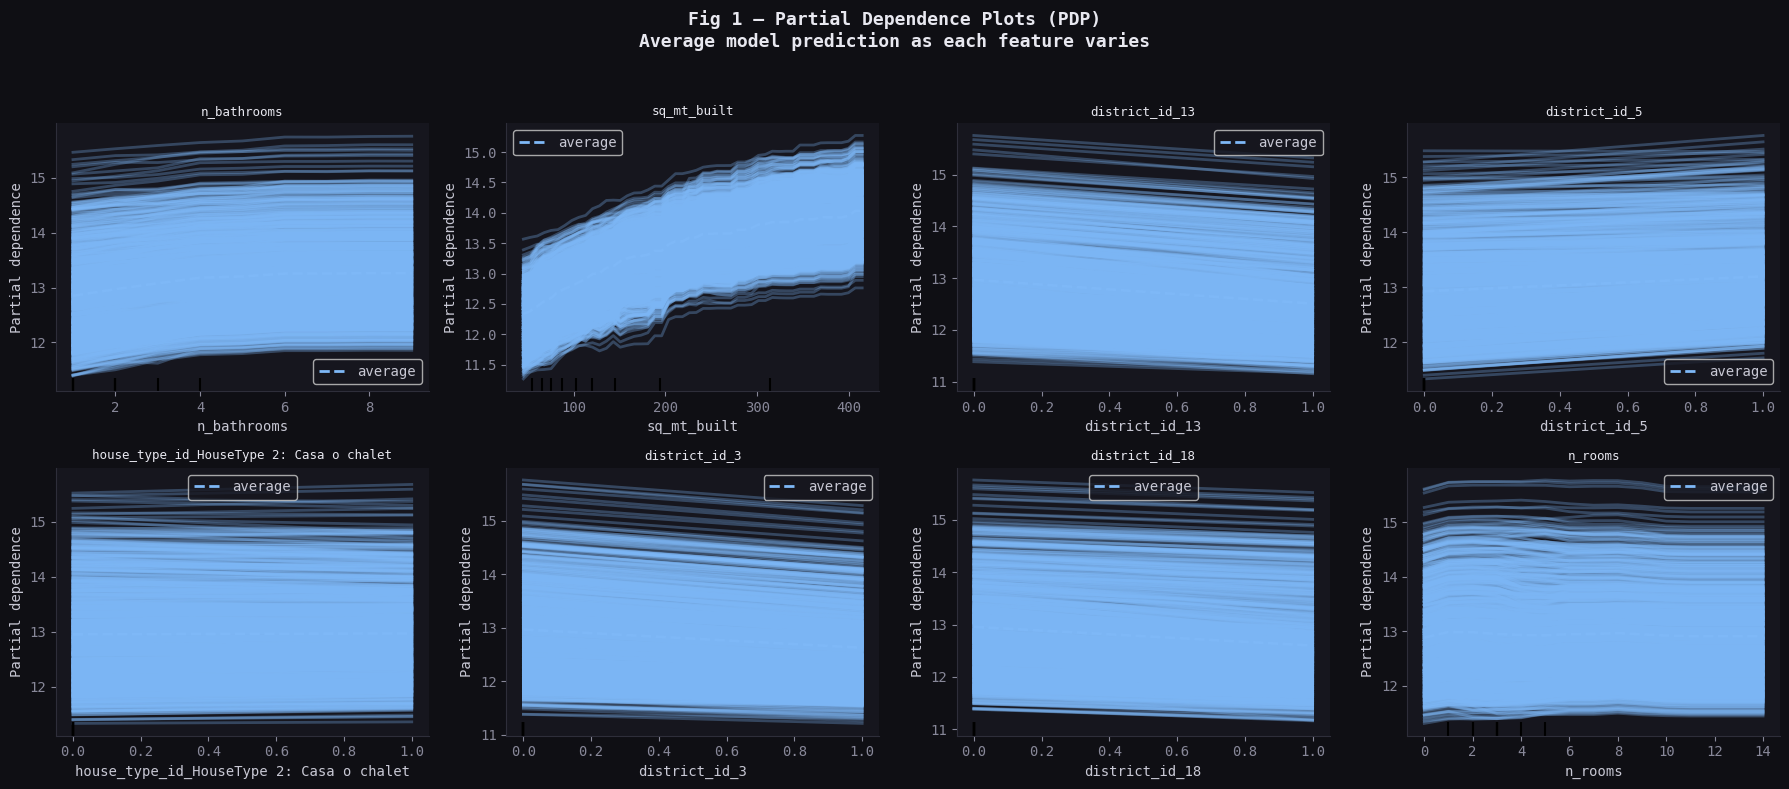

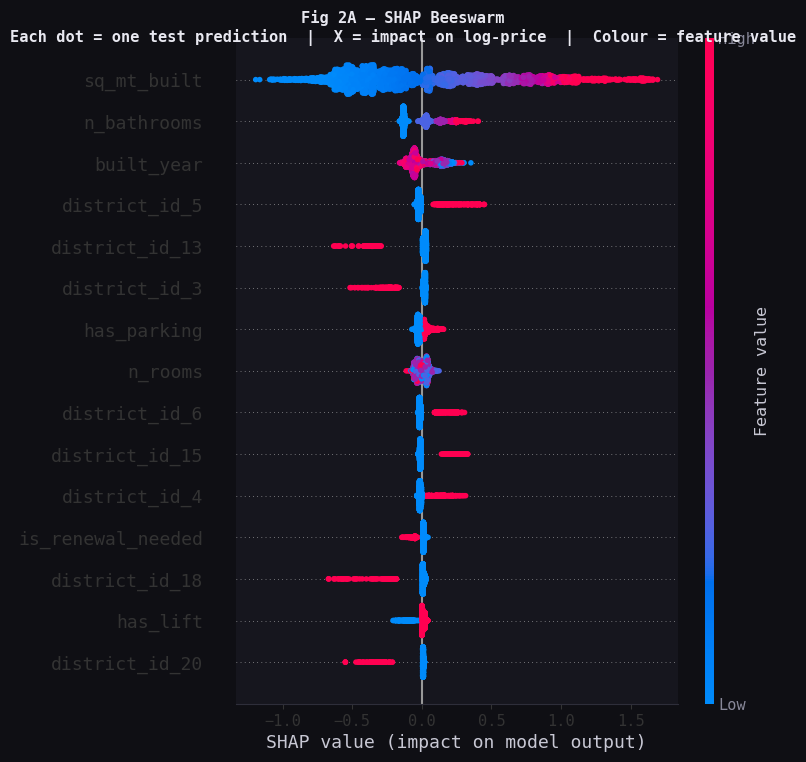

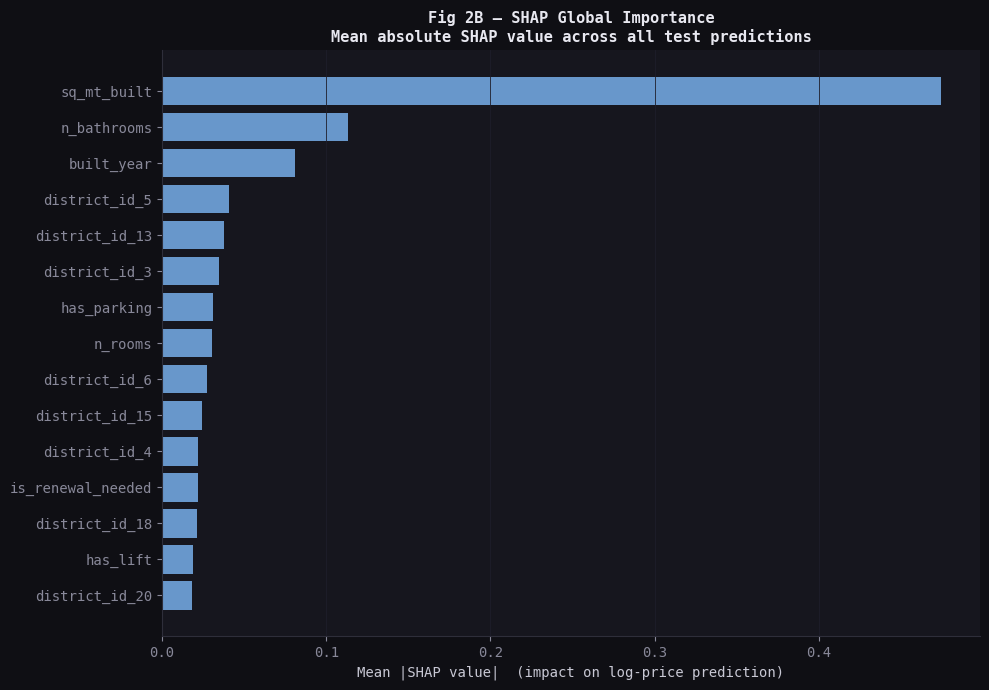

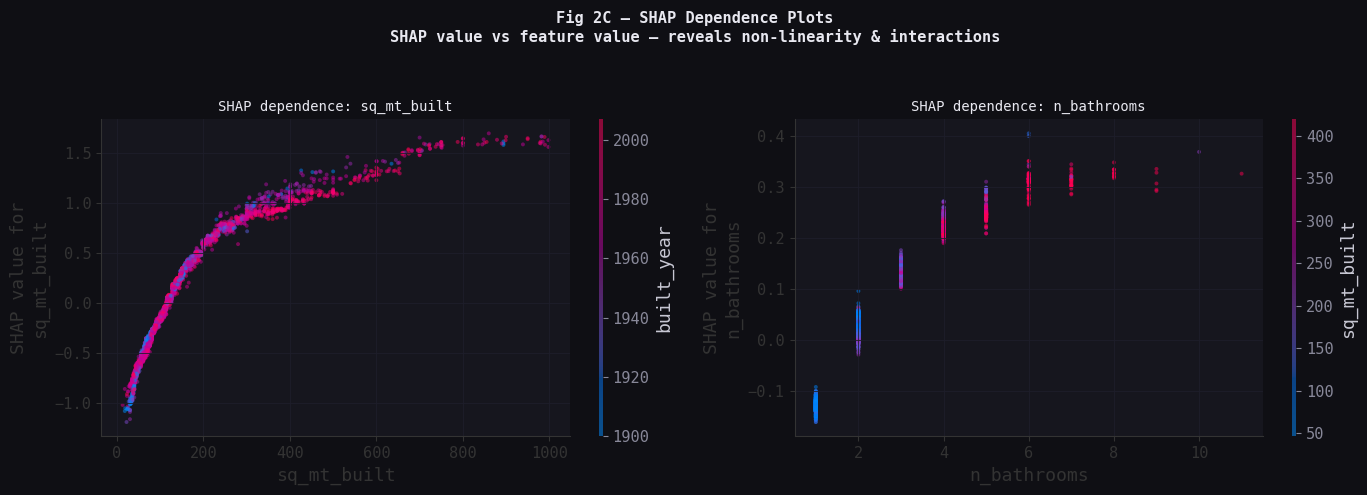

In [427]:
"""
PDP + SHAP — Final Model Interpretability
==========================================
PDP  — what does the model predict ON AVERAGE as one feature changes?
SHAP — how much does each feature contribute to EACH individual prediction?

They answer different questions and are complementary:
  PDP  → global average effect of a feature (marginal effect)
  SHAP → local explanation per sample + global importance ranking
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
from sklearn.inspection import PartialDependenceDisplay

plt.rcParams.update({
    "figure.facecolor": "#0f0f14", "axes.facecolor":  "#16161e",
    "axes.edgecolor":   "#2e2e3a", "axes.labelcolor": "#c8c8d4",
    "axes.titlecolor":  "#e8e8f0", "xtick.color":     "#888899",
    "ytick.color":      "#888899", "text.color":      "#c8c8d4",
    "grid.color":       "#1e1e2a", "font.family":     "monospace",
    "axes.spines.top":  False,     "axes.spines.right": False,
})

# ── Top features by XGBoost gain importance ───────────────────────────────────
# Use gain (not frequency) — gain measures how much each feature
# actually reduces the loss when used in a split, not just how
# often it is picked. A feature split 1000 times with tiny gain
# is less important than one split 10 times with large gain.
importances = pd.Series(
    best_model.get_booster().get_score(importance_type="gain"),
    name="gain"
).sort_values(ascending=False)

top_features = importances.head(10).index.tolist()
print("Top 10 features by gain:")
print(importances.head(10).to_string())


# ════════════════════════════════════════════════════════════════════════════
# FIG 1 — Partial Dependence Plots (PDP)
# ────────────────────────────────────────────────────────────────────────────
# PDP shows: if we force feature X to value v for all rows,
# what is the model's average prediction?
# It marginalises over all other features — shows the "pure" effect
# of one feature holding everything else at its observed distribution.
#
# Limitation: assumes feature independence. If sq_mt_built and
# n_rooms are correlated (they are), the PDP for sq_mt_built
# implicitly includes some of n_rooms' effect. SHAP handles this better.
# ════════════════════════════════════════════════════════════════════════════
print("\nComputing PDP …")

# Use a subsample for speed — PDP on 14k rows × 10 features is slow
sample_idx = np.random.default_rng(42).choice(
    len(X_train), size=min(2000, len(X_train)), replace=False
)
X_pdp = X_train.iloc[sample_idx]

n_features = min(8, len(top_features))
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig1, axes1 = plt.subplots(nrows, ncols,
                            figsize=(18, nrows * 4),
                            facecolor="#0f0f14")
fig1.suptitle("Fig 1 — Partial Dependence Plots (PDP)\n"
              "Average model prediction as each feature varies",
              fontsize=13, fontweight="bold", color="#e8e8f0")

for i, feature in enumerate(top_features[:n_features]):
    ax = axes1.flat[i]
    ax.set_facecolor("#16161e")

    disp = PartialDependenceDisplay.from_estimator(
        best_model, X_pdp,
        features       = [feature],
        kind           = "both",      # pure PDP (not ICE)
        grid_resolution= 50,
        ax             = ax,
        line_kw        = {"color": "#7eb8f7", "lw": 2},
    )

    # PDP y-axis is in log1p(price) — convert ticks to euros
    yticks = ax.get_yticks()
    ax.set_yticklabels(
        [f"€{np.expm1(v)/1e3:.0f}k" for v in yticks], fontsize=7
    )
    ax.set_title(feature, fontsize=9, color="#e8e8f0")
    ax.set_xlabel(feature, fontsize=8)
    ax.set_ylabel("Avg prediction", fontsize=8)
    ax.grid(True, axis="y")

# Hide unused subplots
for j in range(n_features, len(axes1.flat)):
    axes1.flat[j].set_visible(False)

fig1.tight_layout(rect=[0, 0, 1, 0.95])
fig1.savefig("fig1_pdp.png", dpi=150, bbox_inches="tight",
             facecolor=fig1.get_facecolor())
print("Saved → fig1_pdp.png")


# ════════════════════════════════════════════════════════════════════════════
# FIG 2 — SHAP Summary + Beeswarm
# ────────────────────────────────────────────────────────────────────────────
# SHAP (SHapley Additive exPlanations) — Lundberg & Lee 2017
#
# For each prediction, SHAP decomposes it into:
#   prediction = base_value + SHAP(feature_1) + ... + SHAP(feature_n)
#
# SHAP value of feature i for sample j =
#   "how much did feature i push this prediction above/below the mean?"
#
# For XGBoost, TreeExplainer computes exact SHAP values in O(TLD²)
# where T=trees, L=leaves, D=depth — fast and exact (no approximation).
#
# Why SHAP > feature importance from get_score():
#   - gain importance only tells you average effect across all splits
#   - SHAP tells you the effect for EACH individual prediction
#   - SHAP is additive: SHAP values sum exactly to the prediction
#   - SHAP respects feature interactions automatically
# ════════════════════════════════════════════════════════════════════════════
print("Computing SHAP values (TreeExplainer — exact)…")

# TreeExplainer is exact for tree models — no sampling needed
explainer   = shap.TreeExplainer(best_model)

# Use test set — SHAP on held-out data shows real generalisation behaviour
# not memorised patterns from training
shap_values = explainer.shap_values(X_test, approximate=True)   # shape: (n_test, n_features)

# ── Fig 2A: Beeswarm — global feature importance + direction ─────────────────
# Each dot = one test sample
# X position = SHAP value (positive = pushed price up, negative = down)
# Colour     = actual feature value (red = high, blue = low)
# Width      = density of samples at that SHAP value
fig2a, ax2a = plt.subplots(figsize=(11, 8), facecolor="#0f0f14")
ax2a.set_facecolor("#16161e")

shap.summary_plot(
    shap_values, X_test,
    max_display = 15,
    show        = False,
    plot_type   = "dot",
)

fig2a = plt.gcf()
fig2a.set_facecolor("#0f0f14")
fig2a.axes[0].set_facecolor("#16161e")
fig2a.suptitle("Fig 2A — SHAP Beeswarm\n"
               "Each dot = one test prediction  |  "
               "X = impact on log-price  |  Colour = feature value",
               fontsize=11, fontweight="bold", color="#e8e8f0", y=1.01)

fig2a.savefig("fig2a_shap_beeswarm.png", dpi=150, bbox_inches="tight",
              facecolor="#0f0f14")
print("Saved → fig2a_shap_beeswarm.png")

# ── Fig 2B: SHAP bar — mean |SHAP| per feature (global importance) ────────────
fig2b, ax2b = plt.subplots(figsize=(10, 7), facecolor="#0f0f14")
ax2b.set_facecolor("#16161e")

mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=True).tail(15)

bars = ax2b.barh(mean_shap.index, mean_shap.values,
                 color="#7eb8f7", alpha=0.8, edgecolor="none")
ax2b.set_xlabel("Mean |SHAP value|  (impact on log-price prediction)")
ax2b.set_title("Fig 2B — SHAP Global Importance\n"
               "Mean absolute SHAP value across all test predictions",
               fontsize=11, fontweight="bold", color="#e8e8f0")
ax2b.grid(True, axis="x")
fig2b.tight_layout()
fig2b.savefig("fig2b_shap_importance.png", dpi=150, bbox_inches="tight",
              facecolor=fig2b.get_facecolor())
print("Saved → fig2b_shap_importance.png")

# ── Fig 2C: SHAP dependence — one feature's SHAP vs its value ────────────────
# Shows non-linearity + interaction effects that PDP averages out.
# Colour = the feature XGBoost most often pairs with top_feature in splits.
top1 = mean_shap.index[-1]   # highest mean |SHAP|
top2 = mean_shap.index[-2]

fig2c, axes2c = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f0f14")
fig2c.suptitle("Fig 2C — SHAP Dependence Plots\n"
               "SHAP value vs feature value — reveals non-linearity & interactions",
               fontsize=11, fontweight="bold", color="#e8e8f0")

for ax, feat in zip(axes2c, [top1, top2]):
    ax.set_facecolor("#16161e")
    shap.dependence_plot(
        feat, shap_values, X_test,
        ax      = ax,
        show    = False,
        dot_size= 8,
        alpha   = 0.5,
    )
    ax.set_facecolor("#16161e")
    ax.set_title(f"SHAP dependence: {feat}", fontsize=10, color="#e8e8f0")
    ax.grid(True, color="#1e1e2a")

fig2c.tight_layout(rect=[0, 0, 1, 0.93])
fig2c.savefig("fig2c_shap_dependence.png", dpi=150, bbox_inches="tight",
              facecolor=fig2c.get_facecolor())
print("Saved → fig2c_shap_dependence.png")

# ── Fig 2D: Waterfall — single prediction explained ──────────────────────────
# Picks the median-error test sample — most representative single prediction.
# Shows exactly which features pushed the price up or down from the base value.
abs_errors  = np.abs(pred_euros - true_euros)
median_idx  = np.argsort(abs_errors)[len(abs_errors) // 2]

fig2d, ax2d = plt.subplots(figsize=(10, 7), facecolor="#0f0f14")
ax2d.set_facecolor("#16161e")

shap.waterfall_plot(
    shap.Explanation(
        values    = shap_values[median_idx],
        base_values = explainer.expected_value,
        data      = X_test.iloc[median_idx].values,
        feature_names = X_test.columns.tolist(),
    ),
    max_display = 12,
    show        = False,
)

fig2d = plt.gcf()
fig2d.set_facecolor("#0f0f14")
actual  = true_euros.iloc[median_idx] if hasattr(true_euros, "iloc") else true_euros[median_idx]
pred    = pred_euros[median_idx]
fig2d.suptitle(
    f"Fig 2D — SHAP Waterfall (median-error sample)\n"
    f"Actual: €{actual:,.0f}  |  Predicted: €{pred:,.0f}  |  "
    f"Error: €{abs(actual-pred):,.0f}",
    fontsize=10, fontweight="bold", color="#e8e8f0", y=1.01
)
fig2d.savefig("fig2d_shap_waterfall.png", dpi=150, bbox_inches="tight",
              facecolor="#0f0f14")
print("Saved → fig2d_shap_waterfall.png")

plt.show()

In [428]:
X_test.head()

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_rent_price_known,is_renewal_needed,built_year,has_lift,is_exterior,has_parking,...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
3688,100.0,3,1.0,True,False,True,1970.0,True,True,False,...,True,False,False,False,False,False,False,False,False,False
11938,118.0,1,2.0,True,False,False,1950.0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
4040,149.0,4,3.0,True,False,False,1961.0,True,True,True,...,False,False,False,False,False,True,False,False,False,False
3439,44.0,0,1.0,False,False,False,1970.0,True,True,False,...,True,False,False,False,False,False,False,False,False,False
19430,124.0,3,2.0,False,False,True,1957.0,True,True,True,...,True,False,False,False,False,False,False,False,False,False



# Feature importance PDP/SHAP
# Model Safing
# Bias considerations


Overfitting: Training loss continues to decrease, but validation loss begins to rise. The gap becomes large.

Underfitting: Both training and validation loss remain high and parallel, showing the model is too simple to learn the pattern.

Perfect Fit: Both converge low with a minimal gap

Raw data
  └── preprocessing pipeline          (curate, impute, encode)
        └── feature pipeline          (scale, transform)
              └── train / test split  (done once, test locked away)
                    └── nested CV     (model selection + unbiased MAE estimate)
                          └── refit winner on full X_train
                                └── evaluate once on X_test  ← you are here
                                      └── report MAE to stakeholders

Best MAE Baseline: RandomForestRegressor  Fit Time: 6.741s  R2: 0.872  MAE: 115707.564  RMSE: 262904.040

Check:

## Precprocessing:

Basic data cleaning 
(e.g., duplicates)
▪ Zero or constant 
column removal
▪ (generic) Missing 
Value removal
▪ (generic) Feature 
Engineering
▪ (generic) Outlier 
Detection


## Postprocessing:

 Scaling
▪ Missing Value Imputation
▪ Synthetic Data Creation
▪ Feature Encoding
▪ Feature Engineering
▪ Feature Extraction
▪ Feature Selection
▪ Outlier Detection